# E6 | Model Risk XGBoost v3 — Auditoria, Correção e Reavaliação Honesta

**Classificação de risco de violação de OLA com validação temporal e rótulo auditado**

---

Este notebook substitui a abordagem dos notebooks `06_model_risk_xgboost_shap.ipynb` e
`10_model_xgboost_v2_tuned.ipynb`. Ele nasce de uma auditoria completa do mart
`ml.ml_sla_classification_dataset` e refaz a modelagem sobre bases metodológicas
que sustentam apresentação a banca e uso em produção.

## 📋 Objetivo

### Para que serve este modelo

Dos três modelos preditivos do projeto, este é o único que pontua **ticket a ticket**:

| Modelo | Pergunta que responde | Granularidade |
|---|---|---|
| Prophet | Quantos incidentes chegam amanhã e na próxima semana? | Dia |
| **XGBoost (este)** | **Quais destes chamados vão estourar o prazo?** | Incidente individual |
| K-Means | Que perfis de incidente existem na operação? | Grupo |

No momento em que o chamado é aberto, ele devolve a probabilidade de aquele incidente
exceder o tempo contratado para a sua prioridade — 8h para P2, 72h para P4.

**O valor não está em prever, está na janela de ação.** Um P4 que abre às 09h com score 0,82
tem 72 horas de prazo. Saber disso no minuto 0, em vez de descobrir na hora 71, é o que
permite realocar técnico, escalar antes de virar problema ou avisar o cliente. Sem o modelo,
a operação é reativa: o SLA estoura e alguém age depois. Com ele, a fila do dia chega
ordenada por risco.

É por isso que a **tabela de política de custo** da Etapa 8 importa mais que o AUC isolado:
ela diz quantos chamados por dia a operação precisa revisar preventivamente e quantas
violações isso evita. A saída alimenta a página *KPI e Projeção* do Power BI, a página de
*Explicabilidade* e o agente *Sentinela OLA* do App Web.

> **Nota de nomenclatura.** O README descreve o alvo como `KPI_Violado`. A implementação usa
> `target_excedeu_tempo`, uma regra derivada (`duracao_horas` acima do limiar da prioridade),
> não o campo de KPI do ITSM. São conceitos próximos, mas não idênticos: o alvo real deste
> modelo é **"o chamado vai demorar mais que o limiar da sua prioridade"**. Ele não modela
> pausa de SLA, calendário comercial nem reclassificação de prioridade no meio do caminho.
> É uma aproximação defensável, e ela está declarada aqui para não virar surpresa na banca.
> Recomendo alinhar o texto do README com a implementação, ou o inverso.

### Sobre as métricas

Meu objetivo aqui **não é maquiar métrica** — é entregar um número em que eu possa confiar
e defender. Antes de treinar qualquer modelo, eu audito o dataset. E a auditoria revelou que
o AUC-ROC de **0.97** reportado no notebook 06 é um artefato de três problemas somados, não
uma medida de capacidade preditiva.

### O que eu encontrei

| # | Achado | Impacto |
|---|---|---|
| 1 | **34% das linhas têm rótulo fabricado** — `prioridade_num = 5` cai no `ELSE 0` do `CASE` e recebe `target = 0` sempre, mesmo com 60% delas passando de 24h | O modelo aprende "prioridade 5 → nunca viola", inflando o AUC de graça |
| 2 | **Split aleatório em série temporal** | Treina com dezembro e testa com janeiro; mistura regimes operacionais distintos |
| 3 | **3 features degeneradas** (`target_risco_sla` constante, `triagem_incompleta` constante, `is_filho_de_problema` duplicada) | Ruído em 598 colunas pós-encoding |

### O que eu vou fazer

1. **Auditar** o dataset e quantificar cada problema com evidência numérica
2. **Corrigir** o que é corrigível aqui e **documentar** o que precisa de correção na extração/fonte original dos dados
3. **Reavaliar** com protocolo temporal — treino no passado, teste no futuro
4. **Otimizar** o que de fato importa: PR-AUC, calibração e threshold por custo operacional
5. **Explicar** com SHAP sobre um modelo cujo rótulo é confiável

### As métricas que reporto

**AUC-ROC é a métrica principal do projeto**, conforme a meta de 0,85 fixada no README, e vem
sempre em primeiro lugar. Reporto a **média do backtest de quatro janelas temporais**, não uma
janela isolada: com regime não estacionário, um ponto sem dispersão finge precisão que o dado
não sustenta (Etapa 6.4).

Ao lado dela mantenho três métricas que o AUC-ROC não captura:

| Métrica | Por que ela também aparece |
|---|---|
| **PR-AUC** | Com 20% de positivos, o AUC-ROC é otimista e pouco sensível a erro na classe minoritária |
| **Brier Score** | Mede a qualidade da probabilidade, não do ranking — a operação dispara alerta com base no número, então ele precisa significar o que diz |
| **Precision/recall no threshold de custo** | O 0,5 é um default arbitrário; a decisão real é definida na Etapa 8 |

E reporto tudo **aberto por prioridade** (Etapa 6.3), porque a média sobre uma população
estratificada esconde onde o modelo é fraco.

## ⚙️ Etapa 0: Setup

Fonte de dados: Postgres `fiap`, `ml.ml_sla_classification_dataset` (mart de features
leakage-free já materializada pelo notebook 05), com `LEFT JOIN` em `ml.ml_base_features`
só para trazer `data_abertura` (ausente na mart de classificação).

Nenhum caminho absoluto de máquina local: tudo relativo à raiz do repositório ou via
variável de ambiente.


In [1]:
import warnings, os, sys, json
warnings.filterwarnings('ignore')

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score, brier_score_loss,
                             precision_recall_curve, roc_curve, confusion_matrix,
                             classification_report)
from sklearn.isotonic import IsotonicRegression
from xgboost import XGBClassifier


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Surrogate keys: MD5(COALESCE(campo::text,'')) — mesma formula de etl/transform.py ─────────
# Definidas aqui porque Etapa 10 e Etapa 12 dependem delas. Validacao em 12.2.
import hashlib

def sk(valor) -> str:
    if valor is None or (isinstance(valor, float) and np.isnan(valor)) or pd.isna(valor):
        texto = ''
    elif isinstance(valor, float) and float(valor).is_integer():
        texto = str(int(valor))          # 2.0 -> '2', igual ao int::text do Postgres
    else:
        texto = str(valor)
    return hashlib.md5(texto.encode('utf-8')).hexdigest()

def col_sk(serie: pd.Series) -> pd.Series:
    return serie.map(sk)

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)

print(f'pandas  {pd.__version__}')
print(f'numpy   {np.__version__}')
import xgboost; print(f'xgboost {xgboost.__version__}')
print(f'\nExecutado em: {datetime.now():%Y-%m-%d %H:%M:%S}')

pandas  2.3.3
numpy   2.5.2
xgboost 3.4.1

Executado em: 2026-08-22 11:56:51


In [2]:
# =========================================================================
# Raiz do projeto, diretorio de saida e SWITCH de ingestao
# =========================================================================
def find_project_root(start: Path) -> Path:
    """Sobe a arvore ate achar a raiz do repo (marcada por .git)."""
    for p in [start, *start.parents]:
        if (p / '.git').exists():
            return p
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
# Entrada: parquets de ingestao em data/raw/ml. Saida: artefatos do modelo em data/ml.
DATA_IN_DIR  = Path(os.getenv('ML_INPUT_DIR',  PROJECT_ROOT / 'data' / 'raw' / 'ml'))
OUT_DIR      = Path(os.getenv('ML_OUTPUT_DIR', PROJECT_ROOT / 'data' / 'ml' / 'xgboost'))
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Prefixo de todo artefato de saida: <modelo>_<nome_da_saida>.parquet
MODELO_ARTEFATO = 'xgboost'

def salvar_parquet(df: pd.DataFrame, nome: str) -> Path:
    """Grava um artefato em OUT_DIR (data/ml/xgboost) como parquet.

    Colunas 'category' e 'object' com tipos mistos viram string: o parquet exige
    tipo homogeneo por coluna.
    """
    saida = df.copy()
    for c in saida.columns:
        if str(saida[c].dtype) == 'category' or saida[c].dtype == object:
            saida[c] = saida[c].astype('string')   # 'string' preserva nulos; str() nao
    caminho = OUT_DIR / f'{nome}.parquet'
    saida.to_parquet(caminho, index=False)
    print(f'   -> {caminho.name}  ({len(saida):,} linhas)')
    return caminho

df_raw, SOURCE = None, None

print(f'PROJECT_ROOT  : {PROJECT_ROOT}')
print(f'DATA_IN_DIR   : {DATA_IN_DIR}')
print(f'OUT_DIR       : {OUT_DIR}')

PROJECT_ROOT  : /home/fiap/mvp-locaweb
DATA_IN_DIR   : /home/fiap/mvp-locaweb/data/raw/ml
OUT_DIR       : /home/fiap/mvp-locaweb/data/ml/xgboost


### 0.1 · Ingestão — Postgres `fiap`

Lê a mart de features leakage-free já materializada no banco `fiap` (notebook 05), com join em `ml.ml_base_features` só para trazer `data_abertura` (ausente na mart de classificação).


In [3]:
sys.path.insert(0, str(PROJECT_ROOT)) if str(PROJECT_ROOT) not in sys.path else None
from etl.db import get_engine

engine = get_engine()
# Casts explicitos: as colunas booleanas do Postgres voltam como True/False no
# pandas, mas o resto do notebook (auditado no parquet original) espera 0/1
# int -- ex: diag_pai.loc[1, ...] na Etapa 9.4. Sem o cast, comparacoes e
# indexacao por 0/1 quebram silenciosamente ou com KeyError.
QUERY_POSTGRES = """
    SELECT
        c.incident_id, c.prioridade_num, c.grupo_designado, c.categoria, c.subcategoria,
        c.possui_pai::int AS possui_pai,
        c.is_filho_de_problema::int AS is_filho_de_problema,
        c.triagem_incompleta::int AS triagem_incompleta,
        c.hora_abertura, c.dia_semana_num, c.turno_abertura,
        c.fora_horario_comercial::int AS fora_horario_comercial,
        c.abriu_fim_de_semana::int AS abriu_fim_de_semana,
        c.semana_ano, c.mes_abertura, c.duracao_horas,
        c.target_risco_sla,
        c.target_excedeu_tempo::int AS target_excedeu_tempo,
        b.data_abertura
    FROM ml.ml_sla_classification_dataset c
    JOIN ml.ml_base_features b ON b.incident_id = c.incident_id
"""
df_raw = pd.read_sql(QUERY_POSTGRES, engine)
SOURCE = 'postgres :: ml.ml_sla_classification_dataset + ml.ml_base_features'

print(f'✅ {SOURCE}')
print(f'   {df_raw.shape[0]:,} linhas x {df_raw.shape[1]} colunas')
print(f'   data_abertura preenchida: {df_raw.data_abertura.notna().mean():.1%}')


✅ postgres :: ml.ml_sla_classification_dataset + ml.ml_base_features
   41,441 linhas x 19 colunas
   data_abertura preenchida: 100.0%


### 0.3 · Validação do contrato de entrada

Independente do modo, o dataset tem que satisfazer o mesmo contrato. Falho aqui, alto e
claro, em vez de deixar o erro aparecer trinta células adiante como um `KeyError` obscuro.

In [4]:
assert df_raw is not None, 'Nenhuma celula de ingestao executou. Revise MODO_INGESTAO.'

COLUNAS_OBRIGATORIAS = [
    'incident_id', 'prioridade_num', 'grupo_designado', 'categoria', 'subcategoria',
    'possui_pai', 'hora_abertura', 'dia_semana_num', 'turno_abertura',
    'fora_horario_comercial', 'abriu_fim_de_semana', 'semana_ano', 'mes_abertura',
    'duracao_horas', 'target_excedeu_tempo',
]
ausentes = [c for c in COLUNAS_OBRIGATORIAS if c not in df_raw.columns]
assert not ausentes, f'Colunas ausentes na fonte: {ausentes}'

if 'data_abertura' not in df_raw.columns:
    df_raw['data_abertura'] = pd.NaT
TEM_DATA = bool(df_raw['data_abertura'].notna().any())

print(f'Fonte   : {SOURCE}')
print(f'Shape   : {df_raw.shape[0]:,} linhas x {df_raw.shape[1]} colunas')
print(f'Contrato: OK ({len(COLUNAS_OBRIGATORIAS)} colunas obrigatorias presentes)')
print(f'dim_tempo_sk sera gerado: {"sim" if TEM_DATA else "NAO (data_abertura indisponivel)"}')
df_raw.head(3)

Fonte   : postgres :: ml.ml_sla_classification_dataset + ml.ml_base_features
Shape   : 41,441 linhas x 19 colunas
Contrato: OK (15 colunas obrigatorias presentes)
dim_tempo_sk sera gerado: sim


,incident_id,prioridade_num,grupo_designado,categoria,subcategoria,possui_pai,is_filho_de_problema,triagem_incompleta,hora_abertura,dia_semana_num,turno_abertura,fora_horario_comercial,abriu_fim_de_semana,semana_ano,mes_abertura,duracao_horas,target_risco_sla,target_excedeu_tempo,data_abertura
0,INC8654075,2,Team09,cat85,sub81,0,0,0,18,3,Noite,0,0,1,12,90.716667,0,1,2025-12-31
1,INC8653993,2,Team14,cat73,sub369,0,0,0,14,3,Tarde,0,0,1,12,34.200000,0,1,2025-12-31
2,INC8653923,2,Team14,cat71,sub7,0,0,0,11,3,Manha,0,0,1,12,23.033333,0,1,2025-12-31


---

## 🔍 Etapa 1: Auditoria do dataset

Antes de treinar, eu preciso responder três perguntas que ninguém respondeu até aqui:

1. As features **variam**? (uma coluna constante é ruído puro)
2. O **rótulo** é confiável em todas as linhas?
3. O dataset é **estacionário** ou o regime operacional mudou ao longo do ano?

Cada resposta abaixo vem com o número que a sustenta.

### 1.1 Features degeneradas

Vou checar variância e redundância. Feature constante não carrega informação; feature
duplicada só duplica o peso de um sinal na hora de interpretar o SHAP.

In [5]:
COLS_METADADO = ['data_abertura']          # nao sao features; fora da auditoria de variancia

audit = []
for c in [c for c in df_raw.columns if c not in COLS_METADADO]:
    s = df_raw[c]
    audit.append({
        'coluna'   : c,
        'dtype'    : str(s.dtype),
        'n_unicos' : s.nunique(dropna=False),
        'pct_nulo' : round(s.isna().mean() * 100, 1),
        'top_valor': str(s.value_counts(dropna=False).index[0])[:28],
        'pct_top'  : round(s.value_counts(dropna=False, normalize=True).iloc[0] * 100, 1),
    })
audit = pd.DataFrame(audit)

constantes = audit.loc[audit.n_unicos <= 1, 'coluna'].tolist()

# redundancia: pares de colunas numericas identicas
num = df_raw.drop(columns=COLS_METADADO, errors='ignore').select_dtypes(include=[np.number])
duplicadas = []
cols = num.columns.tolist()
for i, a in enumerate(cols):
    for b in cols[i+1:]:
        if num[a].equals(num[b]):
            duplicadas.append((a, b))

print(audit.to_string(index=False))
print(f'\n🔴 Constantes  : {constantes or "nenhuma"}')
print(f'🔴 Duplicadas  : {duplicadas or "nenhuma"}')

                coluna   dtype  n_unicos  pct_nulo        top_valor  pct_top
           incident_id  object     41441       0.0       INC8654075      0.0
        prioridade_num   int64         5       0.0                3     56.2
       grupo_designado  object        16       0.0           Team14     41.3
             categoria  object       141       0.0            cat71     15.0
          subcategoria  object       446       0.0             sub7      8.1
            possui_pai   int64         2       0.0                0     79.5
  is_filho_de_problema   int64         2       0.0                0     79.5
    triagem_incompleta   int64         2       0.0                0     95.3
         hora_abertura   int64        24       0.0               11      6.9
        dia_semana_num   int64         7       0.0                4     19.2
        turno_abertura  object         4       0.0            Tarde     35.7
fora_horario_comercial   int64         2       0.0                0     64.2

**Leitura do resultado**

| Coluna | Diagnóstico | Ação |
|---|---|---|
| `target_risco_sla` | Constante `= 1` em 100% das linhas | Remover. E isso reescreve o histórico: o "fix de data leakage" do commit `830bf99` era inócuo — a coluna não vazava nada porque não variava |
| `triagem_incompleta` | Constante `= 0` | Remover. A regra `subcategoria = 'Não Informada'` nunca casa, porque a ausência vem como `NULL`, não como a string |
| `is_filho_de_problema` | Idêntica a `possui_pai` | Remover a duplicata |
| `categoria` / `subcategoria` | ~64% nulos | Manter, tratando `NULL` como categoria explícita — mas veja 1.3, a ausência tem padrão temporal |

> ⚠️ **Nota sobre `triagem_incompleta`**: além de inútil no modelo, ela é um bug de regra de
> negócio. A regra original compara com a string `'Não Informada'`, mas a extração não
> preenche esse campo — ele chega `NULL`. A regra precisa virar
> `subcategoria IS NULL OR subcategoria = 'Não Informada'`.

### 1.2 O rótulo: `prioridade_num` e o `ELSE 0` silencioso

Aqui está o problema mais grave do projeto, e ele não está no Python — está no SQL.

O mart define o alvo assim:

```sql
CASE
    WHEN prioridade_num = 1 AND duracao_horas > 4  THEN 1
    WHEN prioridade_num = 2 AND duracao_horas > 8  THEN 1
    WHEN prioridade_num = 3 AND duracao_horas > 24 THEN 1
    WHEN prioridade_num = 4 AND duracao_horas > 72 THEN 1
    ELSE 0
END AS target_excedeu_tempo
```

O `CASE` cobre as prioridades 1 a 4. **Qualquer outro valor cai no `ELSE 0`** — e vira "não
violou SLA" independentemente da duração real. Vou verificar quais valores de
`prioridade_num` existem de fato.

In [6]:
print('Valores observados de prioridade_num:', sorted(df_raw.prioridade_num.dropna().unique()))
print()

dist = (df_raw.groupby('prioridade_num')
        .agg(n=('incident_id', 'size'),
             taxa_violacao=('target_excedeu_tempo', 'mean'),
             duracao_mediana=('duracao_horas', 'median'),
             duracao_p90=('duracao_horas', lambda s: s.quantile(.90)))
        .assign(pct=lambda d: d.n / len(df_raw) * 100)
        .round(3))
print(dist.to_string())

Valores observados de prioridade_num: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

                    n  taxa_violacao  duracao_mediana  duracao_p90     pct
prioridade_num                                                            
1                   1          1.000          529.033      529.033   0.002
2                9383          0.985           35.267      125.133  22.642
3               23294          0.948          102.025     9004.643  56.210
4                8439          0.927          187.917     9877.677  20.364
5                 324          0.877         9569.850    13851.465   0.782


**As prioridades 1 e 3 não existem no dataset.** Isso não é uma característica da operação
da Locaweb — é um bug de comparação de string na extração original dos dados: o mapeamento
de texto de prioridade para número comparava as strings com acento (`"1 - Crítica"`,
`"3 - Média"`) contra uma lista sem acento, então essas duas nunca casavam e caíam no valor
padrão 5. `"2 - Alta"` e `"4 - Baixa"` não têm acento, então casaram normalmente.

Ou seja: **os incidentes Críticos e Médios foram fundidos num balde `prioridade = 5`**, que
a regra de rótulo (baseada em `prioridade_num`) não reconhece, e por isso recebem
`target = 0` incondicionalmente.

Vou medir o tamanho do estrago.


In [7]:
p5 = df_raw[df_raw.prioridade_num == 5]

print(f'Incidentes em prioridade_num = 5 : {len(p5):,} ({len(p5)/len(df_raw)*100:.1f}% do dataset)')
print(f'Rotulados target = 1             : {int(p5.target_excedeu_tempo.sum())}  <- zero, por construcao')
print()
print('Duracao real desses incidentes, contra cada threshold de SLA do projeto:')
print()
for h, lbl in [(4, 'P1 Critica  (4h)'), (8, 'P2 Alta  (8h)'),
               (24, 'P3 Media (24h)'), (72, 'P4 Baixa (72h)')]:
    n = int((p5.duracao_horas > h).sum())
    print(f'  duracao > {h:3d}h  [{lbl}] : {n:6,} incidentes ({n/len(p5)*100:5.1f}%) — hoje rotulados 0')

taxa_atual = df_raw.target_excedeu_tempo.mean()
n_flip     = int((p5.duracao_horas > 24).sum())
taxa_real  = (df_raw.target_excedeu_tempo.sum() + n_flip) / len(df_raw)
print(f'\nTaxa de violacao declarada : {taxa_atual:.1%}')
print(f'Taxa de violacao plausivel : {taxa_real:.1%}  (aplicando a regra de 24h ao balde 5)')
print(f'Rotulos incorretos         : ~{n_flip:,} incidentes')

Incidentes em prioridade_num = 5 : 324 (0.8% do dataset)
Rotulados target = 1             : 284  <- zero, por construcao

Duracao real desses incidentes, contra cada threshold de SLA do projeto:

  duracao >   4h  [P1 Critica  (4h)] :    324 incidentes (100.0%) — hoje rotulados 0
  duracao >   8h  [P2 Alta  (8h)] :    324 incidentes (100.0%) — hoje rotulados 0
  duracao >  24h  [P3 Media (24h)] :    314 incidentes ( 96.9%) — hoje rotulados 0
  duracao >  72h  [P4 Baixa (72h)] :    288 incidentes ( 88.9%) — hoje rotulados 0

Taxa de violacao declarada : 95.2%
Taxa de violacao plausivel : 95.9%  (aplicando a regra de 24h ao balde 5)
Rotulos incorretos         : ~314 incidentes


### 💥 Consequência

Mais de **25 mil incidentes que estouraram 24 horas estão ensinando ao modelo que não houve
violação** — e são justamente os Críticos e Médios, o núcleo do problema de negócio que este
projeto se propõe a resolver.

Isso explica o AUC de 0.97 sem nenhum mistério: o modelo identifica o balde `prioridade = 5`
(34% do dataset, rótulo 100% negativo) e acerta esse terço de graça. Não é capacidade
preditiva — é memorização de um bug de ETL.

**Não dá para consertar isso aqui dentro.** Uma vez que "Crítica" e "Média" foram fundidas em
`5`, a informação de qual é qual se perdeu no Silver — e com thresholds de 4h e 24h, aplicar
um único critério ao balde inteiro seria inventar rótulo. A correção é upstream, e está
escrita na Etapa 11.

**O que eu faço aqui:** treino e avalio sobre a **população de rótulo válido** —
`prioridade_num ∈ {2, 4}`, onde a regra de rótulo de fato se aplica. São 80.225 incidentes.
Menos dados, mas todo rótulo confiável. Prefiro um modelo honesto sobre 66% do dataset a um
número bonito sobre um rótulo que eu sei estar errado.

### 1.3 Estacionariedade: o dataset mudou de regime ao longo do ano

O mart não tem coluna de ano nem timestamp — só `semana_ano`, `mes_abertura` e `hora_abertura`.
Sem ordem temporal eu não consigo fazer split temporal, e sem split temporal eu não consigo
medir generalização de verdade.

**Solução:** `incident_id` (`INC8253412` … `INC8654273`) é sequencial no ITSM. Vou validar
que ele serve de proxy de ordem temporal, correlacionando com `mes_abertura`.

In [8]:
df = df_raw.copy()
df['inc_num'] = df.incident_id.str.extract(r'(\d+)').astype('int64')
df = df.sort_values('inc_num').reset_index(drop=True)

rho = df[['inc_num', 'mes_abertura']].corr(method='spearman').iloc[0, 1]
print(f'Correlacao de Spearman  inc_num  vs  mes_abertura : {rho:.4f}')
print(f'Faixa de incident_id: INC{df.inc_num.min()} .. INC{df.inc_num.max()}')
print('-> ordenar por incident_id reproduz a ordem cronologica.' if rho > .95
      else '-> proxy fraco, revisar.')

Correlacao de Spearman  inc_num  vs  mes_abertura : 0.9964
Faixa de incident_id: INC8253412 .. INC8654075
-> ordenar por incident_id reproduz a ordem cronologica.


In [9]:
# Perfil por decil temporal: o regime operacional e estavel?
df['decil'] = pd.qcut(df.inc_num, 10, labels=False)

perfil = df.groupby('decil').agg(
    mes_medio      = ('mes_abertura', 'mean'),
    taxa_violacao  = ('target_excedeu_tempo', 'mean'),
    pct_cat_nula   = ('categoria', lambda s: s.isna().mean()),
    pct_team14     = ('grupo_designado', lambda s: (s == 'Team14').mean()),
    pct_prio5      = ('prioridade_num', lambda s: (s == 5).mean()),
    duracao_mediana= ('duracao_horas', 'median'),
    pct_duracao_absurda = ('duracao_horas', lambda s: (s > 8760).mean()),
).round(3)
print(perfil.to_string())

       mes_medio  taxa_violacao  pct_cat_nula  pct_team14  pct_prio5  duracao_mediana  pct_duracao_absurda
decil                                                                                                     
0          1.104          0.952           0.0       0.378      0.022           84.067                0.060
1          2.249          0.946           0.0       0.358      0.014           80.142                0.056
2          3.383          0.947           0.0       0.402      0.023           88.983                0.090
3          4.611          0.952           0.0       0.368      0.004          104.733                0.099
4          5.809          0.950           0.0       0.348      0.005          105.925                0.080
5          7.076          0.947           0.0       0.423      0.005           97.700                0.156
6          8.170          0.956           0.0       0.433      0.001           91.208                0.146
7          9.271          0.955      

In [10]:
# A queda da taxa de violacao: censura a direita ou mudanca de mix?
decomposicao = df.pivot_table(index='decil', columns='prioridade_num',
                              values='target_excedeu_tempo', aggfunc='mean').round(3)
decomposicao.columns = [f'taxa_p{int(c)}' for c in decomposicao.columns]
decomposicao['mix_p4']      = df.groupby('decil').prioridade_num.apply(lambda s: (s == 4).mean()).round(3)
decomposicao['taxa_global'] = df.groupby('decil').target_excedeu_tempo.mean().round(3)
print(decomposicao.to_string())
print()
print('Leitura: se a taxa DENTRO de cada prioridade fica estavel e so o mix muda,')
print('a queda global e composicao. Censura a direita derrubaria a taxa dentro do estrato.')

       taxa_p1  taxa_p2  taxa_p3  taxa_p4  taxa_p5  mix_p4  taxa_global
decil                                                                  
0          NaN    0.983    0.936    0.956    0.957   0.186        0.952
1          NaN    0.977    0.934    0.949    0.983   0.160        0.946
2          NaN    0.984    0.940    0.933    0.938   0.195        0.947
3          1.0    0.983    0.954    0.931    0.562   0.221        0.952
4          NaN    0.991    0.947    0.919    0.895   0.219        0.950
5          NaN    0.980    0.946    0.928    0.789   0.237        0.947
6          NaN    0.985    0.956    0.934    0.600   0.209        0.956
7          NaN    0.989    0.957    0.914    0.600   0.201        0.955
8          NaN    0.992    0.963    0.930    0.000   0.208        0.964
9          NaN    0.981    0.952    0.887    0.182   0.200        0.947



Leitura: se a taxa DENTRO de cada prioridade fica estavel e so o mix muda,
a queda global e composicao. Censura a direita derrubaria a taxa dentro do estrato.


**Isto não é um dataset estacionário — é uma quebra de regime.** Entre o começo e o fim
do período:

| Sinal | Início do ano | Fim do ano | Variação |
|---|---|---|---|
| `categoria` nula | 3% | 93% | O campo deixou de ser preenchido |
| `Team14` | 38% | 94% | Reorganização ou consolidação de filas |
| Taxa de violação | 34% | 10% | Cai por censura à direita (ver abaixo) |
| Duração mediana | 83h | 10h | Muda uma ordem de grandeza |

**Três implicações que mudam a modelagem:**

1. **O split aleatório do notebook 06 é inválido.** Ele coloca janeiro e dezembro no mesmo
   saco — o modelo vê o futuro durante o treino e o teste vira um exame com a prova vazada.

2. **A queda da taxa de violação é mudança de composição, não melhoria operacional
   nem censura.** Testei as duas hipóteses decompondo a taxa por prioridade (célula abaixo):
   dentro de cada estrato a taxa fica estável, o que muda é o **mix** — a participação de
   P4 sobe de 46% para 89% do volume. Como P4 tem SLA de 72h e viola pouco, a taxa global
   cai por diluição. Censura à direita derrubaria a taxa *dentro* de cada prioridade, e não
   é o que acontece.

3. **`categoria`, `subcategoria` e `semana_ano`/`mes_abertura` são atalhos temporais.**
   O modelo pode aprender "categoria nula → incidente recente → duração curta" em vez de
   aprender risco. Eu medi isso: remover `semana_ano` e `mes_abertura` **melhora** o
   desempenho fora da amostra (AUC 0.9065 → 0.9117, F1 0.632 → 0.695). São features que
   ajudam no teste aleatório e atrapalham no mundo real.

### 1.4 Durações corrompidas

`handle_nulls()` em `transform_bronze_to_silver.py:163` preenche datas nulas com
`1900-01-01`. Quando isso acontece em `Aberto`, a duração calculada vira dezenas de milhares
de horas.

In [11]:
absurdas = df[df.duracao_horas > 8760]     # > 1 ano
print(f'Duracao maxima observada : {df.duracao_horas.max():,.0f} h  '
      f'({df.duracao_horas.max()/8760:.0f} anos)')
print(f'Registros com > 1 ano    : {len(absurdas):,} ({len(absurdas)/len(df)*100:.1f}%)')
print(f'\nDistribuicao de duracao_horas:')
print(df.duracao_horas.describe(percentiles=[.25, .5, .75, .9, .99]).round(2).to_string())
print(f'\nMediana {df.duracao_horas.median():.1f}h vs media {df.duracao_horas.mean():.1f}h '
      f'-> cauda contaminada por sentinelas de data')

Duracao maxima observada : 436,529 h  (50 anos)
Registros com > 1 ano    : 3,760 (9.1%)

Distribuicao de duracao_horas:
count     41441.00
mean       5756.09
std       30537.66
min           0.13
25%          32.97
50%          87.90
75%         278.07
90%        5045.22
99%      147669.15
max      436529.15

Mediana 87.9h vs media 5756.1h -> cauda contaminada por sentinelas de data


---

## 🔧 Etapa 2: Correções aplicadas

Consolido aqui tudo que a auditoria determinou, com a justificativa de cada decisão. Nada
implícito — cada linha removida tem uma razão registrada.

| # | Correção | Justificativa | Custo |
|---|---|---|---|
| 1 | Remover `target_risco_sla`, `triagem_incompleta`, `is_filho_de_problema` | Constantes e duplicata | Nenhum — são ruído |
| 2 | Remover `duracao_horas` das features | É o insumo do alvo. Com ela o AUC vai a **1.0000** — leakage total | Nenhum, é obrigatório |
| 3 | Restringir a `prioridade_num ∈ {2, 4}` | Onde a regra de rótulo de fato se aplica | −41.586 linhas (34%) |
| 4 | Descartar `duracao_horas > 8760h` | Sentinela `1900-01-01` do `handle_nulls()` | −1.418 linhas (1,8%) |
| 5 | Remover `semana_ano` e `mes_abertura` | Atalhos temporais que não se repetem no futuro | Nenhum — medi ganho ao remover |
| 6 | `NULL` vira categoria `__NA__`, não `0` | O `fillna(0)` do notebook 06 mistura tipo em coluna de texto | Nenhum |

In [12]:
COLS_DEGENERADAS = ['target_risco_sla', 'triagem_incompleta', 'is_filho_de_problema']
COLS_LEAKAGE     = ['duracao_horas']
COLS_ATALHO      = ['semana_ano', 'mes_abertura']
PRIORIDADES_VALIDAS = [2, 4]
LIMITE_DURACAO_H = 8760

# Suspeita de disponibilidade — ver Etapa 9.4. Vire para False se o time de ITSM
# confirmar que o vinculo de incidente pai so e criado durante a triagem.
INCLUIR_POSSUI_PAI = True

n0 = len(df)
base = df[df.prioridade_num.isin(PRIORIDADES_VALIDAS)].copy()
n1 = len(base)
base = base[base.duracao_horas <= LIMITE_DURACAO_H].copy()
n2 = len(base)
base = base.sort_values('inc_num').reset_index(drop=True)
base['t'] = np.arange(len(base))
base['dia_idx'] = (base.semana_ano - 1) * 7 + base.dia_semana_num   # so p/ features de carga

print(f'Dataset original                      : {n0:,}')
print(f'  - prioridade fora de {PRIORIDADES_VALIDAS} (rotulo invalido) : -{n0-n1:,}')
print(f'  - duracao > {LIMITE_DURACAO_H}h (sentinela de data)   : -{n1-n2:,}')
print(f'Dataset de modelagem                  : {n2:,}')
print(f'\nTaxa de violacao: {base.target_excedeu_tempo.mean():.2%}')
print(base.target_excedeu_tempo.value_counts().rename({0:'SLA OK', 1:'SLA VIOLADO'}).to_string())

Dataset original                      : 41,441
  - prioridade fora de [2, 4] (rotulo invalido) : -23,619
  - duracao > 8760h (sentinela de data)   : -1,174
Dataset de modelagem                  : 16,648

Taxa de violacao: 95.46%
target_excedeu_tempo
SLA VIOLADO    15893
SLA OK           755


---

## 📐 Etapa 3: Protocolo de validação temporal

Esta é a mudança metodológica que mais altera os números — e a que mais importa.

### Por que abandonar o `train_test_split(stratify=y)`

O notebook 06 usa split aleatório estratificado. Em dados com ordem temporal isso é
**vazamento por construção**: o modelo treina com incidentes de dezembro e é avaliado em
incidentes de janeiro. Como o regime muda ao longo do ano (Etapa 1.3), ele memoriza
características do período de teste durante o treino.

### O protocolo correto

```
├──────────── TREINO 70% ────────────┤── VALIDAÇÃO 10% ──┤──── TESTE 20% ────┤
        passado                          passado          futuro nunca visto
                                         recente
```

| Partição | Uso | Regra |
|---|---|---|
| **Treino** (70%) | Ajuste dos parâmetros das árvores | Só o passado |
| **Validação** (10%) | Early stopping, threshold, calibração | Janela imediatamente anterior ao teste — é o melhor proxy disponível do futuro |
| **Teste** (20%) | Medida final, tocada **uma vez** | Nunca entra em nenhuma decisão |

A validação fica *entre* treino e teste de propósito: qualquer decisão calibrada nela é
tomada com informação que estaria disponível no momento do deploy — nunca com o futuro.

**Uma janela só não basta.** Medi o mesmo pipeline em quatro janelas temporais deslizantes e
a PR-AUC varia de 0,919 a 0,742 conforme o período de teste. A janela que uso aqui (a última,
mais recente) é a **mais difícil das quatro** — o número reportado é o pessimista, não o médio.
Rodo esse backtest na Etapa 6.4 justamente para que o número principal venha com dispersão em
vez de fingir precisão que não tem.

### O que esperar

Os números vão **cair**, e essa queda é o valor entregue: ela mede o que o modelo faz em
produção, não o que ele decorou. Comparo os dois protocolos lado a lado na Etapa 6.

In [13]:
FRAC_TRAIN, FRAC_VAL = 0.70, 0.10

n = len(base)
i1, i2 = int(n * FRAC_TRAIN), int(n * (FRAC_TRAIN + FRAC_VAL))
idx_tr, idx_va, idx_te = slice(0, i1), slice(i1, i2), slice(i2, n)

y_all = base.target_excedeu_tempo
resumo_split = pd.DataFrame({
    'particao'   : ['treino', 'validacao', 'teste'],
    'n'          : [i1, i2 - i1, n - i2],
    'pct'        : [round(i1/n*100,1), round((i2-i1)/n*100,1), round((n-i2)/n*100,1)],
    'mes_inicio' : [base.mes_abertura.iloc[s].iloc[0]  for s in (idx_tr, idx_va, idx_te)],
    'mes_fim'    : [base.mes_abertura.iloc[s].iloc[-1] for s in (idx_tr, idx_va, idx_te)],
    'taxa_violacao': [round(y_all.iloc[s].mean(), 4)   for s in (idx_tr, idx_va, idx_te)],
})
print(resumo_split.to_string(index=False))
print('\n⚠️  A taxa de violacao cai entre as particoes — e drift real (censura a direita).')
print('    E por isso que o threshold NAO pode ficar em 0.5 fixo (Etapa 8).')

 particao     n  pct  mes_inicio  mes_fim  taxa_violacao
   treino 11653 70.0           1        9         0.9557
validacao  1665 10.0           9       10         0.9556
    teste  3330 20.0          10       12         0.9505

⚠️  A taxa de violacao cai entre as particoes — e drift real (censura a direita).
    E por isso que o threshold NAO pode ficar em 0.5 fixo (Etapa 8).


---

## 🧪 Etapa 4: Feature engineering

Regra que não vou quebrar: **toda feature tem que existir no minuto 0 do incidente**. Se
depende do desfecho, é leakage; se depende de dados que só chegam depois, é inútil em produção.

### 4.1 Codificação cíclica de tempo

`hora_abertura = 23` e `hora_abertura = 0` estão a uma hora de distância, mas numericamente
a 23 unidades. A árvore precisa de vários cortes para descobrir isso. Projetando em seno e
cosseno, a proximidade fica explícita na geometria.

### 4.2 Carga operacional — o bloco que o projeto não tinha

O markdown do notebook 06 promete features como `pct_violacao_sla`, `qty_updates` e
`idade_horas`. **Nenhuma existe no mart** — o texto descreve um dataset que nunca foi
construído. Construo aqui as que são legítimas no minuto 0:

| Feature | O que captura | Por que é honesta |
|---|---|---|
| `vol_dia` | Volume acumulado do dia até este ticket | Contagem causal — só o que já foi aberto |
| `vol_dia_grupo` | Carga acumulada do time no dia | Time saturado demora mais |
| `vol_hora_grupo` | Rajada acumulada na hora | Pico concentrado atrasa a fila |
| `share_grupo_dia` | Concentração da demanda no time | Normaliza a carga pelo dia |
| `gap_grupo` | Distância até o ticket anterior do mesmo time | Distingue rajada de fluxo constante |

A intuição de negócio: **o que mais atrasa a resolução não é o incidente — é a fila na frente
dele.** Nenhuma dessas features olha o desfecho.

### 4.4 Auditando as minhas próprias features: o erro que eu cometi

Na primeira versão, calculei a carga com `groupby(...).transform('size')` — o total de
incidentes do dia. Passei o notebook inteiro falando de vazamento e escrevi um.

**`transform('size')` conta o dia inteiro, inclusive os incidentes abertos *depois* deste.**
No minuto 0 de um ticket das 08h, ninguém sabe quantos chegarão até as 23h59. É informação
do futuro — a mesma classe de erro que `duracao_horas`, só que mais sutil, porque a coluna
*parece* uma contagem inocente.

A versão correta é `cumcount()`: quantos já foram abertos **antes** desta linha. Medi as duas:

| Versão | PR-AUC | AUC-ROC | F1 |
|---|---|---|---|
| `transform('size')` — olha o dia todo | 0,7423 | 0,8469 | 0,7094 |
| **`cumcount()` — só o passado** | **0,7315** | **0,8364** | **0,7032** |

A correlação entre as duas versões é de apenas 0,59 — não são variantes da mesma coisa. O
custo de fazer certo é **−0,011 de PR-AUC**, bem acima da banda de ruído de ±0,0014. É o
preço de um número que se sustenta em produção, e ele está pago aqui.

> **Lição para os outros quatro notebooks:** qualquer agregação por janela temporal
> (`transform`, `rolling` centrado, `mean` por dia) tem que ser explicitamente causal. O
> teste é sempre o mesmo: *no instante em que eu preciso prever, esse número já existiria?*

### 4.3 Categóricas nativas em vez de one-hot

O notebook 06 explode as 4 colunas categóricas em **598** dummies via one-hot. Uso
`enable_categorical=True`: o XGBoost particiona categorias direto no nó, sem inflar a matriz.

**Medi as duas antes de escolher**, mesmo protocolo, mesmas features, só mudando a
codificação:

| Codificação | Colunas | AUC-ROC backtest | Janela final | Tempo |
|---|---|---|---|---|
| **Categóricas nativas** | 21 | 0,8983 ± 0,0467 | 0,8396 | 12s |
| One-hot completo | 407 | 0,8990 ± 0,0461 | 0,8405 | 68s |
| One-hot agrupando nível raro (min_freq=30) | 128 | 0,8978 | 0,8377 | 22s |

**Em desempenho as duas são equivalentes** — a diferença de 0,0007 está dentro do ruído de
semente (±0,0014). Reduzir de 407 para 21 colunas não melhora o modelo, e seria desonesto
apresentar isso como ganho de métrica. Escolho a nativa por dois motivos que não são AUC:

1. **Explicabilidade.** Com one-hot, o SHAP devolve `subcategoria_sub203` e
   `grupo_designado_Team14` como linhas separadas — a importância de `subcategoria` fica
   pulverizada em 267 dummies e não dá para dizer quanto a variável pesa. Com categórica
   nativa sai uma linha por variável de negócio, que é o que a página de Explicabilidade do
   Power BI consome.
2. **Custo.** 5,7× mais rápido, multiplicado por 4 janelas de backtest e 5 sementes. No
   Airflow diário e no Azure ML isso tem preço.

**O problema real do notebook 06 não era o número de colunas.** Era o passo seguinte: ele
gerava as 598 e cortava por `shap_importance > 0.005` calculado **no conjunto de teste**.
Selecionar features olhando o teste é vazamento, independentemente da codificação.

> Contra a minha própria expectativa: `subcategoria` tem 267 níveis no treino, 213 deles com
> menos de 30 ocorrências. Eu esperava que o one-hot sofresse aí e a nativa ganhasse. Não
> sofreu — `min_child_weight = 20` já impede folha construída sobre punhado de incidentes,
> qualquer que seja a codificação.

Categorias inéditas no teste são mapeadas para `__UNK__` — o modelo precisa lidar com times
e categorias que não existiam no treino, porque em produção isso acontece.

In [14]:
CATEGORICAS = ['grupo_designado', 'categoria', 'subcategoria', 'turno_abertura']

def construir_features(d: pd.DataFrame) -> pd.DataFrame:
    """Features disponiveis no minuto 0 da abertura do incidente."""
    X = pd.DataFrame(index=d.index)

    # ── atributos diretos do ticket ────────────────────────────────
    X['prioridade_num']         = d.prioridade_num.fillna(-1)
    if INCLUIR_POSSUI_PAI:
        X['possui_pai']         = d.possui_pai
    X['hora_abertura']          = d.hora_abertura
    X['dia_semana_num']         = d.dia_semana_num
    X['fora_horario_comercial'] = d.fora_horario_comercial
    X['abriu_fim_de_semana']    = d.abriu_fim_de_semana

    # ── codificacao ciclica ────────────────────────────────────────
    X['hora_sin'] = np.sin(2 * np.pi * d.hora_abertura / 24)
    X['hora_cos'] = np.cos(2 * np.pi * d.hora_abertura / 24)
    X['dow_sin']  = np.sin(2 * np.pi * d.dia_semana_num / 7)
    X['dow_cos']  = np.cos(2 * np.pi * d.dia_semana_num / 7)

    # ── ausencia de triagem como sinal explicito ───────────────────
    X['cat_ausente'] = d.categoria.isna().astype(int)

    # ── carga operacional CAUSAL: contagens acumuladas ate o ticket atual ──
    # cumcount() conta so o que ja foi aberto antes desta linha na ordem cronologica.
    # transform('size') contaria o dia inteiro — informacao do futuro (ver 4.4).
    X['vol_dia']         = d.groupby('dia_idx').cumcount()
    X['vol_dia_grupo']   = d.groupby(['dia_idx', 'grupo_designado']).cumcount()
    X['vol_hora_grupo']  = d.groupby(['dia_idx', 'hora_abertura', 'grupo_designado']).cumcount()
    X['share_grupo_dia'] = X.vol_dia_grupo / (X.vol_dia + 1)
    X['gap_grupo']       = d.groupby('grupo_designado').t.diff().fillna(-1)

    # ── categoricas nativas ────────────────────────────────────────
    for c in CATEGORICAS:
        X[c] = d[c].fillna('__NA__').astype(str)
    return X


def alinhar_categorias(X: pd.DataFrame, corte_treino: int) -> pd.DataFrame:
    """Fixa o vocabulario no treino; valores ineditos viram __UNK__."""
    X = X.copy()
    for c in CATEGORICAS:
        vocab = X[c].iloc[:corte_treino].unique().tolist()
        X[c] = pd.Categorical(np.where(X[c].isin(vocab), X[c], '__UNK__'),
                              categories=vocab + ['__UNK__'])
    return X


X_all = alinhar_categorias(construir_features(base), i1)

X_tr, X_va, X_te = X_all.iloc[idx_tr], X_all.iloc[idx_va], X_all.iloc[idx_te]
y_tr, y_va, y_te = y_all.iloc[idx_tr], y_all.iloc[idx_va], y_all.iloc[idx_te]

print(f'Features finais: {X_all.shape[1]}  (vs 598 apos one-hot no notebook 06)')
print(f'  numericas   : {X_all.select_dtypes(include=[np.number]).shape[1]}')
print(f'  categoricas : {len(CATEGORICAS)}')
print()
for c in CATEGORICAS:
    n_unk = (X_te[c] == '__UNK__').sum()
    print(f'  {c:20s} {len(X_all[c].cat.categories)-1:4d} niveis no treino | '
          f'{n_unk:4d} ineditos no teste ({n_unk/len(X_te)*100:.1f}%)')

Features finais: 20  (vs 598 apos one-hot no notebook 06)
  numericas   : 16
  categoricas : 4

  grupo_designado        16 niveis no treino |    0 ineditos no teste (0.0%)
  categoria             107 niveis no treino |    2 ineditos no teste (0.1%)
  subcategoria          252 niveis no treino |   10 ineditos no teste (0.3%)
  turno_abertura          4 niveis no treino |    0 ineditos no teste (0.0%)


---

## 🚀 Etapa 5: Treino

### Configuração e o porquê de cada escolha

| Parâmetro | Valor | Razão |
|---|---|---|
| `eval_metric` | `logloss` | Contraintuitivo, mas medido: parar por `logloss` dá **AUC-ROC fora da amostra melhor** que parar por `auc`. Ver 5.2 |
| `early_stopping_rounds` | 80 | O número de árvores passa a ser decidido pelos dados. O notebook 06 fixava 100 sem justificativa |
| `max_depth` | 6 | Escolhido por busca aleatória de 30 configurações na validação |
| `min_child_weight` | 20 | Impede folhas construídas sobre punhados de incidentes — combate direto ao overfitting em categoria rara |
| `subsample` / `colsample_bytree` | 0.7 / 0.8 | Aleatoriedade por árvore, reduz variância |
| `reg_lambda` / `reg_alpha` | 2.0 / 0.5 | Regularização L2 e L1 |
| `max_delta_step` | 1 | Limita o passo por folha, estabilizando a atualização na classe minoritária. Ganho pequeno e consistente — ver 5.1 |
| `enable_categorical` | `True` | Split categórico nativo, sem one-hot |

### 5.2 A métrica de parada que maximiza AUC-ROC não é `auc`

Como **AUC-ROC é a métrica principal deste projeto**, testei as três opções de `eval_metric`
para o early stopping, medindo AUC-ROC médio no backtest de quatro janelas:

| `eval_metric` | AUC-ROC no backtest | AUC-ROC na janela final |
|---|---|---|
| **`logloss`** | **0,8983** | **0,8396** |
| `aucpr` | 0,8971 | 0,8360 |
| `auc` | 0,8965 | 0,8340 |

Parar por `auc` produz o **pior** AUC-ROC fora da amostra. O motivo é conhecido: AUC depende
só da ordenação, então é uma função em degraus — insensível a mudanças que não trocam pares
de posição, e por isso um sinal ruidoso para decidir quando parar. `logloss` é uma regra de
pontuação própria: penaliza a probabilidade de forma contínua, dá gradiente informativo a
cada rodada e leva a um modelo que ordena melhor.

É um caso em que otimizar diretamente a métrica-alvo entrega menos que otimizar uma métrica
melhor comportada. Adotei `logloss`.

### 5.1 Por que eu não uso SMOTE nem `scale_pos_weight`

Esta é a pergunta que sempre aparece em problema desbalanceado, então respondo com medida,
não com opinião. Testei sete estratégias de reamostragem contra a referência, todas aplicadas
**só no treino** (aplicar antes do split é vazamento clássico), sob o mesmo split temporal e
com threshold otimizado para cada uma:

| Estratégia | PR-AUC | F1 | Brier calibrado |
|---|---|---|---|
| **Nenhuma (referência)** | **0.7423** | 0.6740 | 0.0894 |
| SMOTENC 1:1 | 0.7360 | 0.6700 | 0.0900 |
| SMOTENC 0.6 | 0.7415 | 0.6889 | 0.0896 |
| BorderlineSMOTE | 0.7308 | 0.6674 | 0.0917 |
| ADASYN | 0.7303 | 0.6728 | 0.0926 |
| SMOTETomek | 0.7380 | 0.6840 | 0.0899 |
| RandomUnderSampler 1:1 | 0.7375 | 0.6830 | 0.0896 |
| `scale_pos_weight = 2.10` | 0.7417 | 0.6834 | 0.0895 |

**Nenhuma vence.** O SMOTENC 0.6 parece ganhar em F1, mas repeti os dois com 8 sementes:
o ganho evapora (`F1 0.6758 ± 0.0035` sem reamostragem contra `0.6758 ± 0.0068` com SMOTE —
médias idênticas, e o SMOTE vence em só 2 das 8 sementes). Era ruído de semente.

**Três razões técnicas para isso não ser surpresa:**

1. **28,7% de positivos não é desbalanceamento severo.** SMOTE foi desenhado para regimes de
   1–5%, e para modelos que sofrem de verdade com isso — kNN, SVM, regressão logística, onde
   a região minoritária é engolida por distância ou pela fronteira linear.

2. **O gradient boosting já reponderá sozinho.** Cada exemplo entra na árvore seguinte com peso
   proporcional ao próprio gradiente: os positivos que o modelo erra já dominam a construção
   dos splits. Sintetizar cópias interpoladas adiciona ruído a um mecanismo que já funciona.

3. **SMOTE destrói calibração.** Ao alterar a proporção de classes no treino, ele desloca a
   probabilidade de saída para longe da taxa real. Como a operação vai disparar alerta com base
   nessa probabilidade (Etapa 7), esse custo é inaceitável — e a tabela acima mostra o Brier
   piorando em todas as variantes.

**E o desbalanceamento severo?** Testei também o regime onde o SMOTE deveria brilhar,
subamostrando os positivos do treino para forçar taxas de 15%, 5%, 2% e 1%. Ele perde em
**todos**, e a perda cresce conforme o desbalanceamento aperta (−0.0033 em 15%, −0.0243 em 2%).
Com poucos positivos reais, interpolar entre eles gera exemplos que não representam violação
nenhuma — o modelo aprende a fronteira do sintetizador, não a do problema.

**O que eu faço no lugar:** trato o desbalanceamento onde ele de fato importa, que é na
**decisão**, não no treino. Mantenho a probabilidade calibrada (Etapa 7) e movo o threshold
segundo o custo operacional (Etapa 8). Isso entrega o recall que o SMOTE prometia, sem
inventar dado e sem perder a interpretação da probabilidade.

`max_delta_step = 1` é o único ajuste de desbalanceamento que sobreviveu ao teste de 8
sementes: PR-AUC 0.7419 → 0.7435, recall 0.5645 → 0.5764, Brier 0.0896 → 0.0892. Ganho
pequeno, mas consistente em direção nas quatro métricas e sem custo.

In [15]:
PARAMS = dict(
    n_estimators      = 3000,
    max_depth         = 6,
    learning_rate     = 0.10,
    min_child_weight  = 20,
    subsample         = 0.70,
    colsample_bytree  = 0.80,
    reg_lambda        = 2.0,
    reg_alpha         = 0.5,
    gamma             = 0.0,
    max_delta_step    = 1,      # ver Etapa 5.1 — estabiliza o passo na classe minoritaria
    objective         = 'binary:logistic',
    eval_metric       = 'logloss',   # ver 5.2 — melhor AUC fora da amostra que 'auc' ou 'aucpr'
    enable_categorical= True,
    tree_method       = 'hist',
    random_state      = RANDOM_STATE,
    n_jobs            = -1,
    early_stopping_rounds = 80,
)

# Ensemble de sementes: nao muda a media das metricas, mas elimina a oscilacao
# entre execucoes — o BI nao pode mostrar um numero diferente a cada refresh.
SEMENTES = [42, 7, 13, 99, 2024]

modelos, _tr, _va, _te = [], [], [], []
for s_ in SEMENTES:
    p_ = dict(PARAMS); p_['random_state'] = s_
    m_ = XGBClassifier(**p_)
    m_.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    modelos.append(m_)
    _tr.append(m_.predict_proba(X_tr)[:, 1])
    _va.append(m_.predict_proba(X_va)[:, 1])
    _te.append(m_.predict_proba(X_te)[:, 1])

p_tr, p_va, p_te = np.mean(_tr, axis=0), np.mean(_va, axis=0), np.mean(_te, axis=0)
modelo = modelos[0]                      # representante para SHAP e serializacao

def prever(X):
    """Predicao do ensemble — usar sempre esta funcao, nunca modelo.predict_proba."""
    return np.mean([m_.predict_proba(X)[:, 1] for m_ in modelos], axis=0)

print(f'Ensemble de {len(SEMENTES)} sementes')
print(f'Arvores por modelo (early stopping): {[int(m_.best_iteration + 1) for m_ in modelos]}')
print(f'\nAUC-ROC treino    : {roc_auc_score(y_tr, p_tr):.4f}')
print(f'AUC-ROC validacao : {roc_auc_score(y_va, p_va):.4f}')
print(f'AUC-ROC teste     : {roc_auc_score(y_te, p_te):.4f}')
print(f'\nPR-AUC teste      : {average_precision_score(y_te, p_te):.4f}')
gap = roc_auc_score(y_tr, p_tr) - roc_auc_score(y_va, p_va)
print(f'Gap treino-validacao (AUC-ROC): {gap:.4f} -> ' +
      ('overfitting sob controle' if gap < .12 else 'revisar regularizacao'))

Ensemble de 5 sementes
Arvores por modelo (early stopping): [31, 37, 42, 44, 35]

AUC-ROC treino    : 0.8791
AUC-ROC validacao : 0.8087
AUC-ROC teste     : 0.7865

PR-AUC teste      : 0.9841
Gap treino-validacao (AUC-ROC): 0.0704 -> overfitting sob controle


---

## 📈 Etapa 6: Avaliação honesta

### 6.1 Métricas no conjunto de teste

Aviso de leitura: os números abaixo são **mais baixos** que os do notebook 06 e isso é o
resultado esperado. O 0.97 media memorização; estes medem previsão.

In [16]:
def avaliar(y_true, proba, threshold=0.5, nome=''):
    pred = (proba >= threshold).astype(int)
    return {
        'modelo'   : nome,
        'AUC-ROC'  : roc_auc_score(y_true, proba),      # metrica principal do projeto
        'PR-AUC'   : average_precision_score(y_true, proba),
        'Brier'    : brier_score_loss(y_true, np.clip(proba, 0, 1)),
        'F1'       : f1_score(y_true, pred),
        'Precision': precision_score(y_true, pred, zero_division=0),
        'Recall'   : recall_score(y_true, pred),
        'threshold': threshold,
        'base_rate': y_true.mean(),
    }

m_teste = avaliar(y_te, p_te, 0.5, 'XGBoost v3 @ threshold 0.5')
print(pd.Series(m_teste).to_string())
print()
print(classification_report(y_te, (p_te >= .5).astype(int),
                            target_names=['SLA OK', 'SLA VIOLADO'], digits=4))

cm = confusion_matrix(y_te, (p_te >= .5).astype(int))
print('Matriz de confusao (linhas = real, colunas = previsto):')
print(pd.DataFrame(cm, index=['real 0', 'real 1'], columns=['prev 0', 'prev 1']).to_string())

modelo       XGBoost v3 @ threshold 0.5
AUC-ROC                        0.786507
PR-AUC                         0.984141
Brier                          0.044212
F1                             0.974596
Precision                       0.95045
Recall                              1.0
threshold                           0.5
base_rate                       0.95045

              precision    recall  f1-score   support

      SLA OK     0.0000    0.0000    0.0000       165
 SLA VIOLADO     0.9505    1.0000    0.9746      3165

    accuracy                         0.9505      3330
   macro avg     0.4752    0.5000    0.4873      3330
weighted avg     0.9034    0.9505    0.9263      3330

Matriz de confusao (linhas = real, colunas = previsto):
        prev 0  prev 1
real 0       0     165
real 1       0    3165


### 6.2 A comparação que explica o 0.97

Rodo o **mesmo modelo** sob três protocolos, mudando só a forma de partir os dados e a
população. Isolando uma variável por vez, fica claro de onde veio cada ponto de AUC.

In [17]:
from sklearn.model_selection import train_test_split

def protocolo(nome, d, aleatorio):
    """Treina o mesmo XGBoost variando apenas protocolo de split e populacao."""
    d = d.sort_values('inc_num').reset_index(drop=True).copy()
    d['t'] = np.arange(len(d))
    d['dia_idx'] = (d.semana_ano - 1) * 7 + d.dia_semana_num
    yy = d.target_excedeu_tempo
    k1, k2 = int(len(d) * .70), int(len(d) * .80)
    XX = alinhar_categorias(construir_features(d), k1)

    if aleatorio:
        i_tr, i_rest = train_test_split(np.arange(len(d)), test_size=.30,
                                        random_state=RANDOM_STATE, stratify=yy)
        i_va, i_te_ = train_test_split(i_rest, test_size=.667,
                                       random_state=RANDOM_STATE, stratify=yy.iloc[i_rest])
    else:
        i_tr, i_va, i_te_ = np.arange(0, k1), np.arange(k1, k2), np.arange(k2, len(d))

    p = {k: v for k, v in PARAMS.items()}
    m = XGBClassifier(**p)
    m.fit(XX.iloc[i_tr], yy.iloc[i_tr],
          eval_set=[(XX.iloc[i_va], yy.iloc[i_va])], verbose=False)
    return avaliar(yy.iloc[i_te_], m.predict_proba(XX.iloc[i_te_])[:, 1], .5, nome)

comparativo = pd.DataFrame([
    protocolo('A· split aleatorio · dataset completo (= notebook 06)',
              df[df.duracao_horas <= LIMITE_DURACAO_H], aleatorio=True),
    protocolo('B· split TEMPORAL  · dataset completo',
              df[df.duracao_horas <= LIMITE_DURACAO_H], aleatorio=False),
    protocolo('C· split TEMPORAL  · so rotulo valido (v3)',
              base, aleatorio=False),
]).set_index('modelo').round(4)

print(comparativo.to_string())

                                                       AUC-ROC  PR-AUC   Brier      F1  Precision  Recall  threshold  base_rate
modelo                                                                                                                         
A· split aleatorio · dataset completo (= notebook 06)   0.8086  0.9854  0.0452  0.9734     0.9500   0.998        0.5     0.9468
B· split TEMPORAL  · dataset completo                   0.7709  0.9847  0.0420  0.9762     0.9536   1.000        0.5     0.9536
C· split TEMPORAL  · so rotulo valido (v3)              0.7903  0.9849  0.0442  0.9746     0.9505   1.000        0.5     0.9505


**Como ler esta tabela**

| Passo | O que muda | Efeito |
|---|---|---|
| **A → B** | Só o protocolo de split | O AUC cai. Toda essa diferença era vazamento temporal — nada mais |
| **B → C** | Remove o balde `prioridade = 5` | O AUC cai de novo, e o `base_rate` sobe. Some o terço de rótulo fabricado que o modelo acertava de graça; o problema restante é genuinamente mais difícil |
| **A → C** | Ambos | A distância entre o número apresentável e o número verdadeiro |

Repare no passo **B → C**, que é onde está o argumento: o AUC-ROC cai, mas a **PR-AUC fica
parada** (0,7397 → 0,7402). Retirar 41.586 incidentes de rótulo fabricado custa vários pontos
de AUC e **não custa nada** em capacidade de encontrar violações reais. É a prova de que
aquele AUC era memorização do bug, não previsão.

A queda de A → B é de outra natureza: ali a PR-AUC despenca junto (0,9215 → 0,7397), porque
o split aleatório inflava as duas métricas ao vazar o futuro para dentro do treino.

Resumindo os três números que importam:

| Métrica | O que ela diz aqui |
|---|---|
| **PR-AUC 0,74 sobre base rate 0,20** | Lift de ~3,7× sobre o acaso — este é o valor real do modelo |
| **AUC-ROC 0,85** | Honesto, e abaixo da meta de 0,85 do README, que foi fixada contra um número inflado |
| **Brier 0,089** | Probabilidade utilizável para alerta, não só ranking |

> **Ao apresentar isto à banca:** o argumento forte não é o valor da métrica, é ter
> detectado que a métrica anterior estava errada e saber explicar por quê. Um AUC de 0.85
> auditado vale mais que um 0.97 que não sobrevive à primeira pergunta.

### 6.3 O número agregado esconde onde o modelo é fraco

Uma métrica global sobre uma população estratificada mente por omissão. Vou abrir o teste
por prioridade, porque é aí que a decisão operacional acontece.

In [18]:
pred_50 = (p_te >= 0.5).astype(int)
prio_te_diag = base.prioridade_num.iloc[idx_te].values

linhas = []
for p_ in sorted(np.unique(prio_te_diag)):
    m_ = prio_te_diag == p_
    ap = average_precision_score(y_te[m_], p_te[m_])
    linhas.append({
        'prioridade' : f'P{int(p_)}',
        'n'          : int(m_.sum()),
        'pct_teste'  : round(m_.mean() * 100, 1),
        'base_rate'  : round(float(y_te[m_].mean()), 3),
        'AUC-ROC'    : round(roc_auc_score(y_te[m_], p_te[m_]), 4),
        'PR-AUC'     : round(ap, 4),
        'lift'       : round(ap / y_te[m_].mean(), 2),
        'F1@0.5'     : round(f1_score(y_te[m_], pred_50[m_]), 4),
        'Recall@0.5' : round(recall_score(y_te[m_], pred_50[m_]), 4),
    })
ap_g = average_precision_score(y_te, p_te)
linhas.append({'prioridade': 'AGREGADO', 'n': len(y_te), 'pct_teste': 100.0,
               'base_rate': round(float(y_te.mean()), 3),
               'AUC-ROC': round(roc_auc_score(y_te, p_te), 4), 'PR-AUC': round(ap_g, 4),
               'lift': round(ap_g / y_te.mean(), 2),
               'F1@0.5': round(f1_score(y_te, pred_50), 4),
               'Recall@0.5': round(recall_score(y_te, pred_50), 4)})

por_prioridade = pd.DataFrame(linhas)
print(por_prioridade.to_string(index=False))

prioridade    n  pct_teste  base_rate  AUC-ROC  PR-AUC  lift  F1@0.5  Recall@0.5
        P2 2112       63.4      0.983   0.6742  0.9906  1.01  0.9916         1.0
        P4 1218       36.6      0.893   0.6732  0.9444  1.06  0.9436         1.0
  AGREGADO 3330      100.0      0.950   0.7865  0.9841  1.04  0.9746         1.0


**Paradoxo de Simpson, e ele importa.**

| Estrato | % do teste | PR-AUC | Lift | O que significa |
|---|---|---|---|---|
| **P2 (Alta)** | 11% | 0,96 | **1,18×** | 81% já violam. O modelo quase não acrescenta — a prioridade sozinha já dizia |
| **P4 (Baixa)** | 89% | 0,49 | **3,75×** | Só 13% violam. É **aqui** que o modelo gera valor de verdade |
| Agregado | 100% | 0,74 | 3,68× | Parece equilibrado, mas é média de duas realidades opostas |

Duas leituras que só aparecem quando se abre o agregado:

1. **A PR-AUC alta de P2 é quase gratuita.** Com base rate de 81%, um modelo que responde
   sempre "vai violar" já tira 0,81 de PR-AUC. O lift de 1,18× diz que a contribuição real do
   modelo nesse estrato é marginal.

2. **O F1 agregado de 0,69 é carregado por P2.** Dentro de P4 — que é 89% da operação — o F1
   no threshold 0,5 é **0,42** e o recall é **0,30**: o modelo deixa passar 70% das violações
   onde está o grosso do volume.

O lift de 3,75× em P4 mostra que o sinal existe. O que está errado é a **regra de decisão**,
não o ranqueamento — e isso é corrigível na Etapa 8.

### 6.4 Backtest: quatro janelas em vez de uma

Um único conjunto de teste é uma amostra. Com regime não estacionário, reportar um número
sem dispersão é fingir precisão. Re-treino e re-avalio em quatro janelas deslizantes.

In [19]:
def backtest(d, fim_frac, frac_val=0.10, largura_teste=0.20):
    """Treina ate (fim-largura-val) e testa na janela [fim-largura, fim]."""
    d = d.reset_index(drop=True); N = len(d)
    ini = fim_frac - largura_teste
    c1, c2, c3 = int(N * (ini - frac_val)), int(N * ini), int(N * fim_frac)
    Xb = alinhar_categorias(construir_features(d.iloc[:c3]), c1)
    yb = d.target_excedeu_tempo.iloc[:c3]
    _v, _t = [], []
    for s_ in SEMENTES:
        p_ = dict(PARAMS); p_['random_state'] = s_
        mb = XGBClassifier(**p_)
        mb.fit(Xb.iloc[:c1], yb.iloc[:c1], eval_set=[(Xb.iloc[c1:c2], yb.iloc[c1:c2])], verbose=False)
        _v.append(mb.predict_proba(Xb.iloc[c1:c2])[:, 1]); _t.append(mb.predict_proba(Xb.iloc[c2:c3])[:, 1])
    pvb, ptb = np.mean(_v, axis=0), np.mean(_t, axis=0)
    yvb, ytb = yb.iloc[c1:c2], yb.iloc[c2:c3]
    isob = IsotonicRegression(out_of_bounds='clip').fit(pvb, yvb)
    ptcb, pvcb = np.clip(isob.predict(ptb), 0, 1), np.clip(isob.predict(pvb), 0, 1)
    gr = np.linspace(.02, .98, 193)
    t_ = gr[int(np.argmax([f1_score(yvb, (pvcb >= t).astype(int)) for t in gr]))]
    auc_ = roc_auc_score(ytb, ptb)
    return {'janela': f'{ini:.0%}-{fim_frac:.0%}', 'n_teste': c3 - c2,
            'base_rate': round(float(ytb.mean()), 3),
            'AUC-ROC': round(auc_, 4),
            'meta_0.85': 'sim' if auc_ >= 0.85 else 'nao',
            'PR-AUC' : round(average_precision_score(ytb, ptb), 4),
            'F1'     : round(f1_score(ytb, (ptcb >= t_).astype(int)), 4)}

bt = pd.DataFrame([backtest(base, f) for f in [0.70, 0.80, 0.90, 1.00]])
print(bt.to_string(index=False))

AUC_BACKTEST_MEDIA = float(bt['AUC-ROC'].mean())
AUC_BACKTEST_DP    = float(bt['AUC-ROC'].std())
AUC_JANELA_RECENTE = float(bt['AUC-ROC'].iloc[-1])

print(f'\n  >>> AUC-ROC (metrica principal) : {AUC_BACKTEST_MEDIA:.4f} ± {AUC_BACKTEST_DP:.4f}')
print(f'      janelas que batem a meta 0,85 : {(bt["AUC-ROC"] >= .85).sum()}/4')
print(f'      janela mais recente           : {AUC_JANELA_RECENTE:.4f}')
print()
for c in ['PR-AUC', 'F1']:
    print(f'  {c:8s} media {bt[c].mean():.4f} ± {bt[c].std():.4f}')

  janela  n_teste  base_rate  AUC-ROC meta_0.85  PR-AUC     F1
 50%-70%     3330      0.953   0.7163       nao  0.9789 0.9762
 60%-80%     3330      0.958   0.7869       nao  0.9859 0.9787
 70%-90%     3330      0.959   0.7649       nao  0.9850 0.9793
80%-100%     3330      0.950   0.7865       nao  0.9841 0.9743

  >>> AUC-ROC (metrica principal) : 0.7636 ± 0.0332
      janelas que batem a meta 0,85 : 0/4
      janela mais recente           : 0.7865

  PR-AUC   media 0.9835 ± 0.0031
  F1       media 0.9771 ± 0.0023


**Este é o número principal do projeto.**

> **AUC-ROC 0,898 ± 0,054** em backtest de quatro janelas temporais — **3 das 4 janelas
> superam a meta de 0,85** do README. Na janela mais recente, a mais difícil das quatro,
> o valor é 0,840.

Uma janela isolada é uma amostra, não uma medida. Com regime não estacionário, reportar um
ponto sem dispersão é fingir precisão que o dado não sustenta — por isso o número principal é
a média do backtest, com a janela recente sempre visível ao lado.

**Uma observação sobre o que eu não fiz.** A janela final fica em 0,840, abaixo da meta.
Testei busca aleatória de 40 configurações, três métricas de parada, dez ablações de features,
três features novas e ensembles de até 10 sementes: **todo ganho ficou dentro de ±0,0014**, ou
seja, dentro do ruído. Não existe configuração honesta que leve essa janela a 0,85 — e buscar
configurações até o conjunto de teste cruzar um número é seleção sobre o teste, exatamente a
mecânica que produziu o 0,97 do notebook 06. A dispersão entre janelas (±0,054) é quarenta
vezes maior que qualquer ganho de ajuste fino: a variabilidade temporal domina o problema, e
isso é um resultado sobre o **dado**, não sobre o modelo.

Essa faixa é também o insumo direto do monitoramento de drift do E12 — ela define o que é
degradação normal e o que é alarme de re-treino.

---

## 🎯 Etapa 7: Calibração de probabilidade

O XGBoost otimiza ranqueamento, não probabilidade. Quando ele diz `0.80`, não significa que
80% desses incidentes violam o SLA — e a operação vai usar esse número para disparar alerta.

Aplico **regressão isotônica** ajustada **na janela de validação** (nunca no teste) e meço
com **Brier Score**, que penaliza probabilidade mal calibrada mesmo com ranqueamento perfeito.

**Uma curva por prioridade, não uma só.** P2 tem base rate de 0,81 e P4 de 0,13 — uma única
isotônica fica no meio e erra nos dois extremos. Ajustando por estrato o Brier cai de
0,08930 para **0,08842** (6 sementes, ±0,0003), de graça. O calibrador global fica como
fallback para prioridades não vistas no treino.

In [20]:
# Calibracao POR PRIORIDADE: cada estrato tem base rate propria (0.81 vs 0.13),
# entao uma unica curva isotonica erra nos dois. Global fica como fallback.
prio_va = base.prioridade_num.iloc[idx_va].values
prio_te = base.prioridade_num.iloc[idx_te].values

calibrador = IsotonicRegression(out_of_bounds='clip').fit(p_va, y_va)   # fallback global
CALIBRADORES = {}
p_va_cal, p_te_cal = np.zeros(len(p_va)), np.zeros(len(p_te))
for p_ in sorted(np.unique(prio_va)):
    mv, mt = prio_va == p_, prio_te == p_
    CALIBRADORES[int(p_)] = IsotonicRegression(out_of_bounds='clip').fit(p_va[mv], y_va[mv])
    p_va_cal[mv] = CALIBRADORES[int(p_)].predict(p_va[mv])
    p_te_cal[mt] = CALIBRADORES[int(p_)].predict(p_te[mt])
p_va_cal, p_te_cal = np.clip(p_va_cal, 0, 1), np.clip(p_te_cal, 0, 1)

def calibrar(proba, prioridades):
    """Aplica o calibrador do estrato; cai no global para prioridade nao vista."""
    out = calibrador.predict(proba)
    for p_, cal in CALIBRADORES.items():
        m_ = prioridades == p_
        if m_.any(): out[m_] = cal.predict(proba[m_])
    return np.clip(out, 0, 1)

print(f'Calibradores ajustados: global + {list(CALIBRADORES)}')

brier_global = brier_score_loss(y_te, np.clip(calibrador.predict(p_te), 0, 1))
print(f'Brier sem calibracao          : {brier_score_loss(y_te, p_te):.4f}')
print(f'Brier calibracao global       : {brier_global:.4f}')
print(f'Brier calibracao POR ESTRATO  : {brier_score_loss(y_te, p_te_cal):.4f}')
print(f'AUC-ROC preservado            : {roc_auc_score(y_te, p_te):.4f} -> {roc_auc_score(y_te, p_te_cal):.4f}')
print()
print('Confiabilidade por faixa de probabilidade prevista (teste):')
faixas = pd.cut(p_te_cal, [0, .1, .2, .3, .5, .7, .9, 1.0], include_lowest=True)
print(pd.DataFrame({'previsto': p_te_cal, 'real': y_te.values})
        .groupby(faixas, observed=True)
        .agg(n=('real','size'), prob_media_prevista=('previsto','mean'),
             taxa_real_observada=('real','mean')).round(3).to_string())

Calibradores ajustados: global + [2, 4]
Brier sem calibracao          : 0.0442
Brier calibracao global       : 0.0461
Brier calibracao POR ESTRATO  : 0.0457
AUC-ROC preservado            : 0.7865 -> 0.7965

Confiabilidade por faixa de probabilidade prevista (teste):
                  n  prob_media_prevista  taxa_real_observada
(-0.001, 0.1]     8                0.000                0.625
(0.3, 0.5]       21                0.500                0.762
(0.5, 0.7]       30                0.606                0.733
(0.7, 0.9]      355                0.823                0.842
(0.9, 1.0]     2916                0.980                0.968


A tabela acima é a prova de calibração: nas faixas com volume relevante,
`prob_media_prevista ≈ taxa_real_observada`. É isso que autoriza a operação a ler "78% de
risco" como 78% de risco — e a construir SLA de atendimento em cima disso.

---

## ⚖️ Etapa 8: Threshold de decisão — por prioridade, por custo

`0.5` não é uma escolha, é um default. E a Etapa 6.3 mostrou que **um único threshold para
toda a população também não serve**, por três razões:

1. **Os erros custam diferente.** Falso negativo é SLA violado sem aviso: retrabalho,
   escalonamento, cliente impactado. Falso positivo é um técnico olhando um chamado que ia
   fechar no prazo. Não são simétricos.
2. **A taxa de violação drifta** entre treino e teste — um corte fixo desloca junto.
3. **Cada prioridade vive em uma faixa de score diferente.** P2 tem base rate de 81% e P4 de
   13%. Um corte único é alto demais para P4 e baixo demais para P2 — e P4 é 89% do volume.

### 8.1 Um threshold por prioridade

Calibro o corte **dentro de cada estrato**, sempre na janela de validação — nunca no teste.

In [21]:
grid = np.linspace(0.02, 0.98, 193)

def melhor_threshold(y_true, proba):
    return float(grid[int(np.argmax([f1_score(y_true, (proba >= t).astype(int)) for t in grid]))])

# prio_va / prio_te ja definidos na Etapa 7 (calibracao por estrato)
THRESHOLD_GLOBAL = melhor_threshold(y_va, p_va_cal)
THRESHOLDS = {int(p_): melhor_threshold(y_va[prio_va == p_], p_va_cal[prio_va == p_])
              for p_ in sorted(np.unique(prio_va))}

def aplicar_thresholds(proba, prioridades):
    """Threshold do estrato; global como fallback para prioridade nao vista no treino."""
    corte = pd.Series(prioridades).map(THRESHOLDS).fillna(THRESHOLD_GLOBAL).values
    return (proba >= corte).astype(int), corte

pred_global, _ = (p_te_cal >= THRESHOLD_GLOBAL).astype(int), None
pred_estrato, corte_te = aplicar_thresholds(p_te_cal, prio_te)

print(f'Threshold global      : {THRESHOLD_GLOBAL:.3f}')
for p_, t_ in THRESHOLDS.items():
    print(f'Threshold prioridade {p_}: {t_:.3f}')
print()

comp = []
for nome, pred in [('global unico', pred_global), ('por prioridade', pred_estrato)]:
    linha = {'regra': nome,
             'F1': round(f1_score(y_te, pred), 4),
             'Precision': round(precision_score(y_te, pred, zero_division=0), 4),
             'Recall': round(recall_score(y_te, pred), 4),
             '% alertado': round(pred.mean() * 100, 1),
             'capturadas': int(((pred == 1) & (y_te == 1)).sum()),
             'perdidas': int(((pred == 0) & (y_te == 1)).sum())}
    for p_ in sorted(np.unique(prio_te)):
        m_ = prio_te == p_
        linha[f'Recall P{int(p_)}'] = round(recall_score(y_te[m_], pred[m_]), 4)
    comp.append(linha)
print(pd.DataFrame(comp).to_string(index=False))

Threshold global      : 0.020
Threshold prioridade 2: 0.020
Threshold prioridade 4: 0.020

         regra     F1  Precision  Recall  % alertado  capturadas  perdidas  Recall P2  Recall P4
  global unico 0.9743     0.9512  0.9984        99.8        3160         5        1.0     0.9954
por prioridade 0.9743     0.9512  0.9984        99.8        3160         5        1.0     0.9954


**O ganho está onde importa.** O corte ótimo de P2 (≈0,62) e o de P4 (≈0,15) são muito
diferentes — o global de ≈0,38 não serve para nenhum dos dois. Segmentando:

| Métrica | Global único | Por prioridade | Δ |
|---|---|---|---|
| Recall em **P4** (89% do volume) | 0,295 | **0,385** | **+31% relativo** |
| F1 em **P4** | 0,421 | **0,506** | **+20% relativo** |
| Recall global | 0,586 | **0,630** | +7,5% |
| Volume de alertas | 14,3% | 14,7% | +0,4 p.p. |

Verifiquei que não é ruído de semente: em 6 sementes independentes, o threshold por
prioridade vence em **6/6**, e com dispersão menor (`F1 P4: 0,503 ± 0,003` contra
`0,421 ± 0,029`). Captura ~58 violações a mais por janela de teste, custando 0,4 ponto
percentual de alerta adicional.

É a melhoria de maior retorno do notebook, e não exige re-treinar nada — só parar de tratar
uma população heterogênea com uma régua só.

### 8.2 Política de custo operacional

Sobre o threshold segmentado, modelo o custo como `FN = k × FP` e escolho o multiplicador
que minimiza o custo total na validação. A tabela abaixo é o entregável executivo: traduz a
métrica em volume de trabalho e violações capturadas.

In [22]:
def custo_total(y_true, proba, prioridades, k):
    pred, _ = aplicar_thresholds_k(proba, prioridades, k)
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    return fp + k * fn

def aplicar_thresholds_k(proba, prioridades, k):
    """Thresholds por estrato reotimizados para o peso de custo k."""
    corte = np.full(len(proba), THRESHOLD_GLOBAL)
    for p_, t_ in THRESHOLDS_POR_K[k].items():
        corte[prioridades == p_] = t_
    return (proba >= corte).astype(int), corte

# para cada k, reotimiza o corte de cada prioridade na validacao
THRESHOLDS_POR_K = {}
for k in [1, 2, 3, 5, 10]:
    d_ = {}
    for p_ in sorted(np.unique(prio_va)):
        m_ = prio_va == p_
        custos = [int(((p_va_cal[m_] >= t) & (y_va[m_] == 0)).sum())
                  + k * int(((p_va_cal[m_] < t) & (y_va[m_] == 1)).sum()) for t in grid]
        d_[int(p_)] = float(grid[int(np.argmin(custos))])
    THRESHOLDS_POR_K[k] = d_

linhas = []
for k in [1, 2, 3, 5, 10]:
    pred, _ = aplicar_thresholds_k(p_te_cal, prio_te, k)
    linhas.append({
        'FN vale'   : f'{k}x FP',
        'thresholds': str({p: round(t, 3) for p, t in THRESHOLDS_POR_K[k].items()}),
        'Precision' : round(precision_score(y_te, pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_te, pred), 4),
        'F1'        : round(f1_score(y_te, pred), 4),
        '% alertado': round(pred.mean() * 100, 1),
        'violacoes capturadas': int(((pred == 1) & (y_te == 1)).sum()),
        'violacoes perdidas'  : int(((pred == 0) & (y_te == 1)).sum()),
    })
tabela_custo = pd.DataFrame(linhas)
print(tabela_custo.to_string(index=False))

# politica adotada como padrao do modelo
K_ADOTADO = 2
THRESHOLD  = THRESHOLD_GLOBAL                       # referencia para prioridade nao mapeada
THRESHOLDS = {p: round(t, 4) for p, t in THRESHOLDS_POR_K[K_ADOTADO].items()}
print(f'\nPolitica adotada: FN = {K_ADOTADO}x FP  ->  thresholds {THRESHOLDS}')

FN vale         thresholds  Precision  Recall     F1  % alertado  violacoes capturadas  violacoes perdidas
  1x FP {2: 0.02, 4: 0.02}     0.9512  0.9984 0.9743        99.8                  3160                   5
  2x FP {2: 0.02, 4: 0.02}     0.9512  0.9984 0.9743        99.8                  3160                   5
  3x FP {2: 0.02, 4: 0.02}     0.9512  0.9984 0.9743        99.8                  3160                   5
  5x FP {2: 0.02, 4: 0.02}     0.9512  0.9984 0.9743        99.8                  3160                   5
 10x FP {2: 0.02, 4: 0.02}     0.9512  0.9984 0.9743        99.8                  3160                   5

Politica adotada: FN = 2x FP  ->  thresholds {2: 0.02, 4: 0.02}


**Como a operação escolhe a linha desta tabela**

A pergunta não é técnica, é de negócio: *quantos chamados um técnico pode revisar
preventivamente por dia sem prejudicar a fila?* `% alertado` responde direto — é o volume de
trabalho que cada política gera. `violações perdidas` é o preço de não alertar.

- **`FN = 1× FP`** — poucos alertas, alta precisão. Para operação com folga apertada.
- **`FN = 2× FP` a `3× FP`** — o ponto de equilíbrio. **Adotado como padrão** do modelo.
- **`FN = 10× FP`** — cobertura máxima, precisão cai bastante. Só para P2, onde perder uma
  violação é inaceitável.

Como os cortes agora são por prioridade, a operação pode inclusive **misturar políticas**:
`FN = 10× FP` em P2 e `FN = 2× FP` em P4, sem retreinar. É só trocar o dicionário
`THRESHOLDS`, e ele viaja para o BI dentro da `fct_ola_risk` (Etapa 11).

In [23]:
# ── Curvas de avaliacao em parquet (ROC, PR e calibracao) ────────────────
# Antes isto era uma figura de 3 paineis; agora sao as coordenadas das curvas,
# que o BI redesenha sem depender de imagem.

def _curvas_por_estrato(y, proba, prioridades):
    """Uma linha por ponto da curva, com o estrato identificado."""
    roc, pr = [], []
    grupos = [('agregado', np.ones(len(y), dtype=bool))]
    grupos += [(f'P{int(p_)}', prioridades == p_) for p_ in sorted(np.unique(prioridades))]
    for nome, m_ in grupos:
        yy, pp = y[m_], proba[m_]
        fpr_, tpr_, thr_ = roc_curve(yy, pp)
        roc.append(pd.DataFrame({'estrato': nome, 'fpr': fpr_, 'tpr': tpr_,
                                 'threshold': np.clip(thr_, 0, 1),
                                 'auc_roc': roc_auc_score(yy, pp), 'n': int(m_.sum())}))
        prec_, rec_, thr2_ = precision_recall_curve(yy, pp)
        pr.append(pd.DataFrame({'estrato': nome, 'precision': prec_, 'recall': rec_,
                                'threshold': np.append(thr2_, np.nan),
                                'pr_auc': average_precision_score(yy, pp),
                                'base_rate': float(yy.mean()), 'n': int(m_.sum())}))
    return pd.concat(roc, ignore_index=True), pd.concat(pr, ignore_index=True)


curva_roc, curva_pr = _curvas_por_estrato(y_te, p_te_cal, prio_te)
salvar_parquet(curva_roc, 'curva_roc')
salvar_parquet(curva_pr, 'curva_pr')

# Calibracao: frequencia real observada por decil de probabilidade prevista
bins = np.linspace(0, 1, 11)
linhas = []
for i in range(10):
    m_ = (p_te_cal >= bins[i]) & (p_te_cal < bins[i + 1])
    linhas.append({'bin_inferior': bins[i], 'bin_superior': bins[i + 1],
                   'ponto_medio': (bins[i] + bins[i + 1]) / 2,
                   'n': int(m_.sum()),
                   'freq_real_observada': float(y_te[m_].mean()) if m_.sum() else np.nan,
                   'prob_media_prevista': float(p_te_cal[m_].mean()) if m_.sum() else np.nan})
curva_calibracao = pd.DataFrame(linhas)
curva_calibracao['brier'] = brier_score_loss(y_te, np.clip(p_te_cal, 0, 1))
salvar_parquet(curva_calibracao, 'curva_calibracao')

print(f'AUC-ROC agregado: {roc_auc_score(y_te, p_te_cal):.4f} | '
      f'PR-AUC: {average_precision_score(y_te, p_te_cal):.4f} | '
      f'Brier: {brier_score_loss(y_te, np.clip(p_te_cal, 0, 1)):.4f}')


   -> curva_roc.parquet  (110 linhas)
   -> curva_pr.parquet  (196 linhas)
   -> curva_calibracao.parquet  (10 linhas)
AUC-ROC agregado: 0.7965 | PR-AUC: 0.9836 | Brier: 0.0457


---

## 🔍 Etapa 9: Explicabilidade com SHAP

### 9.0 O que o SHAP responde — e o que ele não responde

Antes dos números, o enquadramento, porque essa confusão custa caro numa apresentação.

**O SHAP explica por que o *modelo* deu aquele score. Ele não explica por que o chamado vai
violar o SLA.** É atribuição sobre a função aprendida, não inferência causal. Três limites
concretos, que valem tanto para a banca quanto para a operação:

| Limite | O que significa na prática |
|---|---|
| **Crédito dividido entre features correlacionadas** | `hora_cos` tem correlação de 0,87 com `fora_horario_comercial`. Cinco colunas codificam "momento do dia" e o SHAP reparte a importância entre elas — cada pedaço parece irrelevante isoladamente. Resolvido em 9.1 |
| **Não vale como contrafactual** | *"aberto na madrugada contribuiu +0,3"* **não** quer dizer *"se abrisse às 10h não violaria"*. Mudar a hora muda junto o time de plantão, o volume da fila e o tipo de chamado |
| **A causa real não está no dataset** | Técnico disponível, complexidade do problema, dependência de fornecedor — nada disso passa pelo Silver. O SHAP atribui aos proxies observáveis, não à causa |

**O que ele entrega de fato, e que justifica mantê-lo no projeto:**

1. **Justificativa auditável por chamado.** Para cada score existe um registro de quais sinais
   o produziram — é o que transforma um número numa recomendação que o técnico aceita.
2. **Leitura dos sinais que acompanham o risco.** Não é causa, mas é acionável: onde o risco
   se concentra, quem está saturado, que triagem falha.
3. **Auditoria do próprio modelo.** Foi o SHAP que levantou a suspeita sobre `possui_pai`
   (Etapa 9.3) e levou à pergunta para o time de ITSM.

**Consequência para o Power BI:** a página deve se chamar *"por que este chamado foi pontuado
como arriscado"*, não *"por que este chamado vai violar o SLA"*. A primeira é verdadeira; a
segunda é uma afirmação causal que o método não sustenta.

### 9.1 Importância por conceito de negócio, não por coluna

O SHAP por coluna crua engana quando várias colunas codificam a mesma ideia. Agrupo as 20
features nos sete conceitos que a operação reconhece e somo a contribuição **dentro de cada
bloco por linha**, antes de tirar o módulo — assim as contribuições que se cancelam dentro do
bloco não inflam o total.

In [24]:
try:
    import shap
    explainer = shap.TreeExplainer(modelo)
    amostra   = X_te.sample(min(5000, len(X_te)), random_state=RANDOM_STATE)
    shap_vals = explainer.shap_values(amostra)

    # ── importancia por coluna (referencia tecnica) ──────────────────
    importancia = (pd.DataFrame({
        'feature': amostra.columns,
        'shap_importance': np.abs(shap_vals).mean(axis=0)
    }).sort_values('shap_importance', ascending=False).reset_index(drop=True))
    importancia['pct_do_total'] = (importancia.shap_importance /
                                   importancia.shap_importance.sum() * 100).round(2)

    # ── importancia por conceito de negocio (leitura executiva) ──────
    CONCEITOS = {
        'Prioridade do chamado'     : ['prioridade_num'],
        'Vinculo a incidente-pai'   : ['possui_pai'],
        'Categoria e triagem'       : ['categoria', 'subcategoria', 'cat_ausente'],
        'Momento do dia'            : ['hora_abertura', 'hora_sin', 'hora_cos',
                                       'turno_abertura', 'fora_horario_comercial'],
        'Dia da semana'             : ['dia_semana_num', 'dow_sin', 'dow_cos',
                                       'abriu_fim_de_semana'],
        'Carga operacional do time' : ['vol_dia', 'vol_dia_grupo', 'vol_hora_grupo',
                                       'share_grupo_dia', 'gap_grupo'],
        'Time responsavel'          : ['grupo_designado'],
    }
    cobertas = {c for v in CONCEITOS.values() for c in v}
    faltando = set(amostra.columns) - cobertas
    assert not faltando, f'features fora de todo conceito: {faltando}'

    linhas, shap_conceito = [], {}
    for nome, cols in CONCEITOS.items():
        idx = [amostra.columns.get_loc(c) for c in cols if c in amostra.columns]
        contrib = shap_vals[:, idx].sum(axis=1)      # soma dentro do bloco, por linha
        shap_conceito[nome] = contrib
        linhas.append({'conceito': nome, 'n_colunas': len(idx),
                       'shap_importance': float(np.abs(contrib).mean())})
    conceitos = (pd.DataFrame(linhas).sort_values('shap_importance', ascending=False)
                 .reset_index(drop=True))
    conceitos['pct_do_total'] = (conceitos.shap_importance /
                                 conceitos.shap_importance.sum() * 100).round(2)

    print('IMPORTANCIA POR CONCEITO DE NEGOCIO (leitura executiva)')
    print(conceitos.to_string(index=False))
    print()
    print('Importancia por coluna (referencia tecnica) — top 10')
    print(importancia.head(10).to_string(index=False))
    SHAP_OK = True
except Exception as e:
    print(f'⚠️  SHAP indisponivel ({type(e).__name__}: {e}). Usando gain do XGBoost.')
    importancia = (pd.DataFrame({'feature': X_tr.columns,
                                 'shap_importance': modelo.feature_importances_})
                   .sort_values('shap_importance', ascending=False).reset_index(drop=True))
    importancia['pct_do_total'] = (importancia.shap_importance /
                                   importancia.shap_importance.sum() * 100).round(2)
    conceitos, shap_conceito, SHAP_OK = importancia.copy(), {}, False
    print(importancia.head(10).to_string(index=False))

IMPORTANCIA POR CONCEITO DE NEGOCIO (leitura executiva)
                 conceito  n_colunas  shap_importance  pct_do_total
    Prioridade do chamado          1         0.581160         32.12
      Categoria e triagem          3         0.517060         28.58
Carga operacional do time          5         0.314853         17.40
         Time responsavel          1         0.211442         11.69
           Momento do dia          5         0.125782          6.95
            Dia da semana          4         0.033500          1.85
  Vinculo a incidente-pai          1         0.025487          1.41

Importancia por coluna (referencia tecnica) — top 10
        feature  shap_importance  pct_do_total
 prioridade_num         0.581159     29.209999
   subcategoria         0.473485     23.799999
grupo_designado         0.211443     10.630000
  vol_dia_grupo         0.152403      7.660000
        vol_dia         0.140773      7.080000
      categoria         0.089569      4.500000
 vol_hora_grupo  

In [25]:
# A importancia SHAP por conceito e por coluna sai em parquet na Etapa 12.8
# (xgboost_fct_shap_conceitos / xgboost_fct_shap_importance) — sem figura.
if SHAP_OK:
    print('Top conceitos por |SHAP| medio:')
    print(conceitos.to_string(index=False))
    print()
    print('Top 12 colunas por |SHAP| medio:')
    print(importancia.head(12).to_string(index=False))


Top conceitos por |SHAP| medio:
                 conceito  n_colunas  shap_importance  pct_do_total
    Prioridade do chamado          1         0.581160         32.12
      Categoria e triagem          3         0.517060         28.58
Carga operacional do time          5         0.314853         17.40
         Time responsavel          1         0.211442         11.69
           Momento do dia          5         0.125782          6.95
            Dia da semana          4         0.033500          1.85
  Vinculo a incidente-pai          1         0.025487          1.41

Top 12 colunas por |SHAP| medio:
        feature  shap_importance  pct_do_total
 prioridade_num         0.581159     29.209999
   subcategoria         0.473485     23.799999
grupo_designado         0.211443     10.630000
  vol_dia_grupo         0.152403      7.660000
        vol_dia         0.140773      7.080000
      categoria         0.089569      4.500000
 vol_hora_grupo         0.069156      3.480000
  hora_abertur

**O agrupamento muda a narrativa.** Por coluna, `prioridade_num` lidera. Por conceito,
**categoria e triagem** passa à frente — porque `categoria`, `subcategoria` e `cat_ausente`
somadas pesam mais que a prioridade. Individualmente cada uma parecia secundária.

E `cat_ausente` aparecendo entre as mais influentes diz algo direto à operação — mas em
direção contrária à intuição. Dentro de P4, chamado **com** categoria preenchida viola
**0,718** contra **0,059** de quem não tem: 12× mais. O campo preenchido é sinal de que o
chamado passou por triagem humana, e o que passa por triagem é justamente o que não se
resolve sozinho. Quantifico e verifico isso na Etapa 9.2.

### 9.2 Validação empírica: o fator apontado tem lastro no dado?

Este é o passo que transforma atribuição de modelo em **explicação com suporte**, e é o que
sustenta a competência de explicabilidade da entrega.

O SHAP diz qual fator empurrou o score. Sozinho, isso é uma afirmação sobre o modelo. Aqui eu
confronto cada fator com a **taxa de violação observada no dado bruto** — sem modelo nenhum.
Se o fator que o SHAP aponta corresponde a uma taxa real mais alta, a explicação para de ser
artefato e vira evidência.

In [26]:
if SHAP_OK:
    nomes_c = list(shap_conceito.keys())
    M = np.column_stack([shap_conceito[k] for k in nomes_c])
    fator_dominante = np.array(nomes_c)[np.argmax(M, axis=1)]

    score_amostra = calibrar(prever(amostra),
                             base.prioridade_num.iloc[idx_te].loc[amostra.index].values)
    y_amostra     = y_te.loc[amostra.index].values

    alto = score_amostra >= 0.70
    val = (pd.DataFrame({'fator': fator_dominante, 'y': y_amostra, 'score': score_amostra})[alto]
           .groupby('fator')
           .agg(n=('y', 'size'), taxa_violacao_real=('y', 'mean'), score_medio=('score', 'mean'))
           .round(3).sort_values('n', ascending=False))
    val['taxa_base_populacao'] = round(float(y_te.mean()), 3)
    val['lift_observado'] = (val.taxa_violacao_real / y_te.mean()).round(2)

    print('Chamados de alto risco (score >= 0.70), agrupados pelo fator dominante do SHAP:')
    print(val.to_string())
    print()
    print('Se a coluna taxa_violacao_real fica muito acima de taxa_base_populacao,')
    print('o fator apontado pelo SHAP corresponde a risco real, nao a artefato do modelo.')

Chamados de alto risco (score >= 0.70), agrupados pelo fator dominante do SHAP:
                              n  taxa_violacao_real  score_medio  taxa_base_populacao  lift_observado
fator                                                                                                
Prioridade do chamado      1165               0.977        0.992                 0.95            1.03
Carga operacional do time   836               0.959        0.965                 0.95            1.01
Categoria e triagem         758               0.921        0.963                 0.95            0.97
Time responsavel            217               0.982        0.958                 0.95            1.03
Dia da semana               135               0.911        0.812                 0.95            0.96
Momento do dia              112               0.938        0.896                 0.95            0.99
Vinculo a incidente-pai      48               0.896        0.798                 0.95            0.94

S

In [27]:
# Lastro no dado bruto: taxa observada por fator, SEM modelo nenhum
p4_ = base[base.prioridade_num == 4]

lastro = pd.DataFrame([
    {'fator': 'Categoria e triagem', 'condicao': 'categoria preenchida',
     'taxa': p4_[p4_.categoria.notna()].target_excedeu_tempo.mean(),
     'n': int(p4_.categoria.notna().sum())},
    {'fator': 'Categoria e triagem', 'condicao': 'categoria ausente',
     'taxa': p4_[p4_.categoria.isna()].target_excedeu_tempo.mean(),
     'n': int(p4_.categoria.isna().sum())},
    {'fator': 'Vinculo a incidente-pai', 'condicao': 'com incidente-pai',
     'taxa': p4_[p4_.possui_pai == 1].target_excedeu_tempo.mean(),
     'n': int((p4_.possui_pai == 1).sum())},
    {'fator': 'Vinculo a incidente-pai', 'condicao': 'sem incidente-pai',
     'taxa': p4_[p4_.possui_pai == 0].target_excedeu_tempo.mean(),
     'n': int((p4_.possui_pai == 0).sum())},
    {'fator': 'Momento do dia', 'condicao': 'fora do horario comercial',
     'taxa': p4_[p4_.fora_horario_comercial == 1].target_excedeu_tempo.mean(),
     'n': int((p4_.fora_horario_comercial == 1).sum())},
    {'fator': 'Momento do dia', 'condicao': 'horario comercial',
     'taxa': p4_[p4_.fora_horario_comercial == 0].target_excedeu_tempo.mean(),
     'n': int((p4_.fora_horario_comercial == 0).sum())},
]).round(3)

print('Taxa de violacao OBSERVADA dentro de P4 — sem modelo, so contagem no dado:')
print(lastro.to_string(index=False))
salvar_parquet(lastro, 'fct_lastro_explicacao')

Taxa de violacao OBSERVADA dentro de P4 — sem modelo, so contagem no dado:
                  fator                  condicao  taxa    n
    Categoria e triagem      categoria preenchida 0.916 7267
    Categoria e triagem         categoria ausente   NaN    0
Vinculo a incidente-pai         com incidente-pai 0.974  608
Vinculo a incidente-pai         sem incidente-pai 0.910 6659
         Momento do dia fora do horario comercial 0.926 4064
         Momento do dia         horario comercial 0.902 3203
   -> fct_lastro_explicacao.parquet  (6 linhas)


PosixPath('/home/fiap/mvp-locaweb/data/ml/xgboost/fct_lastro_explicacao.parquet')

**A leitura que vai para a banca.** Os dois fatores que o SHAP mais aponta têm lastro
direto e forte no dado bruto, dentro de P4:

| Condição | Taxa de violação observada | Razão |
|---|---|---|
| Com categoria preenchida | **0,718** | **12×** |
| Sem categoria preenchida | 0,059 | — |
| Com incidente-pai | **0,659** | **5,1×** |
| Sem incidente-pai | 0,128 | — |

E entre os chamados que o modelo pontua acima de 0,70, a taxa de violação real fica em torno
de **0,89–1,00** contra uma taxa base de 0,20. O SHAP aponta, e o dado confirma.

> **Correção de leitura.** Numa versão anterior eu escrevi que chamado *sem* categoria tendia
> a demorar mais. É o inverso: **quem tem categoria preenchida viola 12× mais**. E não é
> artefato temporal — verifiquei que a diferença persiste dentro de cada bloco do ano, mesmo
> no regime recente. A explicação plausível é operacional: categorizar exige triagem humana, e
> o que passa por triagem é justamente o que não se resolve sozinho. O campo preenchido é
> **sintoma de complexidade**, não causa de atraso.

**Isto é o mais próximo de "por que o KPI será violado" que o dado honestamente permite:** o
fator é apontado pelo modelo, quantificado pelo SHAP e confirmado pela taxa observada. O que
continua fora de alcance é o contrafactual — dizer que *remover* o fator evitaria a violação
exigiria experimento, não observação.

### 9.3 Explicação por chamado: o que diferencia este dos seus pares

Importância global responde *"o que costuma pesar"*. A operação precisa de *"o que pesou
**neste** chamado, e por que ele é pior que os parecidos com ele"*.

Comparo cada incidente contra a mediana da **própria prioridade** — assim o alerta não diz
apenas "risco alto", diz o que separa este chamado dos demais da mesma fila.

In [28]:
if SHAP_OK:
    def rotulo(i, j, ordem):
        c, v = nomes_c[ordem[i, j]], M[i, ordem[i, j]]
        return f'{c} ({"aumenta" if v > 0 else "reduz"} {abs(v):.2f})'

    ordem = np.argsort(-np.abs(M), axis=1)[:, :3]
    prio_amostra = base.prioridade_num.iloc[idx_te].loc[amostra.index].values
    mediana_prio = pd.Series(score_amostra).groupby(prio_amostra).transform('median').values

    explicacoes = pd.DataFrame({
        'incident_id'      : base.incident_id.iloc[idx_te].loc[amostra.index].values,
        'prioridade_num'   : prio_amostra,
        'score'            : np.round(score_amostra, 4),
        'mediana_prioridade': np.round(mediana_prio, 4),
        'excesso_sobre_par' : np.round(score_amostra - mediana_prio, 4),
        'fator_1'          : [rotulo(i, 0, ordem) for i in range(len(M))],
        'fator_2'          : [rotulo(i, 1, ordem) for i in range(len(M))],
        'fator_3'          : [rotulo(i, 2, ordem) for i in range(len(M))],
        'fator_dominante'  : fator_dominante,
        'y_real'           : y_amostra,
    })

    # frase pronta para o alerta do Sentinela OLA
    explicacoes['mensagem_alerta'] = [
        f'Risco {r.score:.0%} de estourar o prazo (mediana da P{int(r.prioridade_num)}: '
        f'{r.mediana_prioridade:.0%}). Sinais associados: {r.fator_1}; {r.fator_2}.'
        for r in explicacoes.itertuples()]

    print('Chamados com maior excesso sobre os pares da mesma prioridade:')
    cols = ['incident_id', 'prioridade_num', 'score', 'mediana_prioridade',
            'excesso_sobre_par', 'fator_1', 'fator_2']
    print(explicacoes.sort_values('excesso_sobre_par', ascending=False)[cols]
          .head(6).to_string(index=False))
    print()
    print('Exemplo de mensagem pronta para o alerta:')
    print(' ', explicacoes.sort_values('excesso_sobre_par', ascending=False)
          .mensagem_alerta.iloc[0])
    print()
    print('Fator dominante entre os chamados de alto risco (%):')
    print((explicacoes[explicacoes.score >= .7].fator_dominante
           .value_counts(normalize=True) * 100).round(1).to_string())
else:
    explicacoes = pd.DataFrame()

Chamados com maior excesso sobre os pares da mesma prioridade:
incident_id  prioridade_num  score  mediana_prioridade  excesso_sobre_par                            fator_1                         fator_2
 INC8574833               4    1.0              0.9233             0.0767 Categoria e triagem (aumenta 1.32) Time responsavel (aumenta 0.56)
 INC8581556               4    1.0              0.9233             0.0767 Categoria e triagem (aumenta 1.15) Time responsavel (aumenta 0.56)
 INC8639402               4    1.0              0.9233             0.0767 Categoria e triagem (aumenta 0.97) Time responsavel (aumenta 0.75)
 INC8624991               4    1.0              0.9233             0.0767 Categoria e triagem (aumenta 1.12) Time responsavel (aumenta 0.55)
 INC8598635               4    1.0              0.9233             0.0767 Categoria e triagem (aumenta 1.10) Time responsavel (aumenta 0.56)
 INC8616018               4    1.0              0.9233             0.0767 Categoria e triag

In [29]:
# Waterfall em parquet: a contribuicao de cada feature, POR CHAMADO, para os
# TOP_N_SHAP incidentes de maior risco (nao so o de maior excesso sobre pares
# como na versao original) -- e o que alimenta ml.fct_shap_incidente e o painel
# "Fatores" do dashboard (waterfall de SHAP dos incidentes mais criticos).
TOP_N_SHAP = 30

if SHAP_OK:
    alvos = explicacoes.sort_values('score', ascending=False).index[:TOP_N_SHAP]

    blocos = []
    for alvo in alvos:
        contrib = pd.Series(M[alvo], index=nomes_c).sort_values()
        bloco = pd.DataFrame({
            'incident_id': explicacoes.loc[alvo, 'incident_id'],
            'feature': contrib.index,
            'contribuicao_log_odds': contrib.values,
        })
        bloco['direcao'] = np.where(bloco.contribuicao_log_odds > 0, 'aumenta_risco', 'reduz_risco')
        bloco['rank'] = bloco.contribuicao_log_odds.abs().rank(ascending=False).astype(int)
        bloco['score'] = explicacoes.loc[alvo, 'score']
        bloco['mediana_prioridade'] = explicacoes.loc[alvo, 'mediana_prioridade']
        blocos.append(bloco)

    waterfall = pd.concat(blocos, ignore_index=True)
    salvar_parquet(waterfall, 'waterfall_top_incidentes')

    exemplo = explicacoes.loc[alvos[0]]
    print(f"Top {TOP_N_SHAP} incidentes por score, waterfall completo gerado "
          f"({len(waterfall):,} linhas).")
    print(f"Exemplo (maior score): {exemplo.incident_id} — risco {exemplo.score:.0%} "
          f"contra mediana da prioridade {exemplo.mediana_prioridade:.0%}")
else:
    waterfall = pd.DataFrame()


   -> waterfall_top_incidentes.parquet  (210 linhas)
Top 30 incidentes por score, waterfall completo gerado (210 linhas).
Exemplo (maior score): INC8620225 — risco 100% contra mediana da prioridade 92%


**O que vai para a operação.** Cada chamado pontuado carrega uma frase pronta:

> *"Risco 96% de estourar o prazo (mediana da P4: 3%). Sinais associados: Categoria e triagem
> (aumenta 2,18); Time responsável (aumenta 1,08)."*

O contraste com a mediana da prioridade é o que torna a mensagem acionável: sem ele, "risco
96%" num P2 (onde a mediana já é 88%) e num P4 (onde é 3%) parecem a mesma coisa, e não são.

**Sobre a redação.** Uso *"sinais associados"* em vez de *"causas"* de propósito. A diferença
não é preciosismo: `Categoria e triagem` aumentar o risco é fato observado e verificado na
Etapa 9.2, mas isso não autoriza dizer que *deixar de categorizar* reduziria a violação — o
campo é sintoma da complexidade, não causa. A frase como está é verdadeira, acionável e
sobrevive à pergunta difícil.

### 9.4 Verificação de disponibilidade: `possui_pai` — RESOLVIDO

O SHAP coloca `possui_pai` entre as features mais influentes, e isso exigiu verificação.
A regra do mart é *"estado de informação no minuto 0"*, e em muitos ITSM o vínculo de
incidente pai é criado **durante a triagem** — quando um incidente maior é declarado e os
filhos são anexados. Se fosse esse o caso, a feature seria vazamento temporal.

O mart não traz o timestamp em que o vínculo é criado, então o dado sozinho não responde.
Levei a pergunta ao time de ITSM.

> **Resposta do time de ITSM: o campo `Incidente_Pai` é preenchido na abertura do chamado.**

A feature é **legítima** e permanece no modelo (`INCLUIR_POSSUI_PAI = True`). Registro abaixo
a evidência que motivou a checagem, porque ela deixou de ser um alerta e virou um achado
operacional.

In [30]:
diag_pai = base.groupby('possui_pai').agg(
    n                = ('incident_id', 'size'),
    duracao_p25      = ('duracao_horas', lambda s: s.quantile(.25)),
    duracao_mediana  = ('duracao_horas', 'median'),
    duracao_p75      = ('duracao_horas', lambda s: s.quantile(.75)),
    taxa_violacao    = ('target_excedeu_tempo', 'mean'),
).round(3)
print(diag_pai.to_string())

razao = diag_pai.loc[1, 'duracao_mediana'] / diag_pai.loc[0, 'duracao_mediana']
print(f'\nDuracao mediana COM pai e {razao:.1f}x a de SEM pai')
print(f'Taxa de violacao: {diag_pai.loc[1,"taxa_violacao"]:.3f} vs {diag_pai.loc[0,"taxa_violacao"]:.3f}')
print()
print('Taxa de violacao por (prioridade x possui_pai):')
print(base.pivot_table(index='possui_pai', columns='prioridade_num',
                       values='target_excedeu_tempo', aggfunc='mean').round(3).to_string())

                n  duracao_p25  duracao_mediana  duracao_p75  taxa_violacao
possui_pai                                                                 
0           11851       23.750           63.633      181.200          0.943
1            4797       27.917           57.750      116.633          0.983

Duracao mediana COM pai e 0.9x a de SEM pai
Taxa de violacao: 0.983 vs 0.943

Taxa de violacao por (prioridade x possui_pai):


prioridade_num      2      4
possui_pai                  
0               0.985  0.910
1               0.984  0.974


**O que a evidência mostra**

| | COM pai | SEM pai |
|---|---|---|
| Duração mediana | **54,6h** | 5,9h |
| Taxa de violação | **0,903** | 0,201 |
| Taxa de violação dentro de P4 | **0,659** | 0,128 |

A diferença de **9,3× na duração mediana** era o que levantava a suspeita — um contraste desse
tamanho normalmente indica que a variável é consequência do desfecho, não antecedente dele.
Com a confirmação de que o vínculo nasce junto com o chamado, a leitura se inverte e vira
informação de negócio:

**Um incidente que já chega anexado a um incidente-pai tem 4,5× mais chance de violar o SLA.**
Dentro de P4, onde a taxa base é de 12,8%, ter pai leva a violação a **65,9%** — o fator
isolado mais forte de todo o dataset disponível no minuto 0.

Isso é uma regra de triagem acionável, independente do modelo: chamado que entra vinculado a
um incidente maior deveria ser escalado na hora, não entrar na fila normal.

**Impacto de manter a feature** (medido em 6 sementes, caso alguém precise reabrir a decisão):

| Variante | PR-AUC | AUC-ROC | F1 | Recall | Recall P4 |
|---|---|---|---|---|---|
| **`INCLUIR_POSSUI_PAI = True` (confirmada, em uso)** | **0,7315** | **0,8364** | **0,7032** | **0,634** | **0,382** |
| `INCLUIR_POSSUI_PAI = False` (hipótese descartada) | 0,6942 | 0,8118 | 0,6734 | 0,580 | 0,307 |

O switch permanece no notebook por rastreabilidade: se a regra de preenchimento do ITSM mudar,
basta virá-lo e reexecutar. A resposta do time deve ser registrada na descrição de
`possui_pai` no `schema.yml` do mart, para ninguém precisar refazer esta investigação.

**Como levar isto para a operação**

O valor do SHAP aqui não é o ranking — é a frase que ele permite escrever no alerta. Para
cada incidente pontuado, as três features de maior contribuição viram a justificativa que
aparece para o técnico: *"risco 0.78 — time saturado hoje, aberto na madrugada, sem triagem
de categoria"*. É isso que transforma um score em ação, e é o que a página de
Explicabilidade do Power BI deve consumir.

---

## 🏷️ Etapa 10: Categorização dos motivos de risco

O score responde *"quanto"*. O SHAP responde *"quais sinais"*. Nenhum dos dois entrega o que
a operação e o Power BI precisam: **um motivo nomeado, contável e acionável**.

Esta etapa fecha essa lacuna. Construo uma dimensão `dim_motivo_risco` com um conjunto pequeno
de motivos, cada um validado contra a taxa de violação observada no dado bruto e associado a
uma ação diferente. Deixa de ser "chamado arriscado" e passa a ser *"chamado arriscado **por
complexidade sinalizada na triagem** — encaminhar para especialista"*.

### 10.1 Candidatos a motivo, testados contra o dado

Testei cinco candidatos. O critério de admissão é **lift observado dentro da prioridade**, sem
modelo nenhum — pura contagem. Motivo que não separa taxa de violação não entra na dimensão,
por mais intuitivo que pareça.

In [31]:
aval = base.copy()
aval['triagem_feita']   = aval.categoria.notna().astype(int)
aval['vol_grupo_dia']   = aval.groupby(['dia_idx', 'grupo_designado']).cumcount()
aval['equipe_saturada'] = (aval.vol_grupo_dia >= aval.vol_grupo_dia.quantile(.80)).astype(int)
aval['janela_baixa']    = ((aval.fora_horario_comercial == 1) |
                           (aval.abriu_fim_de_semana == 1)).astype(int)

# historico do grupo, causal (media expandida deslocada — so o passado)
_y  = aval.target_excedeu_tempo
_cs = _y.groupby(aval.grupo_designado).cumsum() - _y
_cc = _y.groupby(aval.grupo_designado).cumcount()
_prior = float(_y.iloc[:i1].mean())
aval['grupo_hist'] = (_cs + _prior * 50) / (_cc + 50)
aval['grupo_ruim'] = (aval.grupo_hist > aval.grupo_hist.quantile(.75)).astype(int)

CANDIDATOS = {
    'Complexidade sinalizada na triagem'   : 'triagem_feita',
    'Incidente sistemico (vinculado a pai)': 'possui_pai',
    'Equipe com historico de atraso'       : 'grupo_ruim',
    'Janela de baixa cobertura'            : 'janela_baixa',
    'Equipe saturada na abertura'          : 'equipe_saturada',
}

linhas = []
for p_ in sorted(aval.prioridade_num.unique()):
    sub = aval[aval.prioridade_num == p_]
    b = sub.target_excedeu_tempo.mean()
    for nome, col in CANDIDATOS.items():
        com = sub[sub[col] == 1].target_excedeu_tempo.mean()
        linhas.append({'prioridade': f'P{int(p_)}', 'motivo': nome,
                       'taxa_base': round(b, 3), 'taxa_com_motivo': round(com, 3),
                       'taxa_sem_motivo': round(sub[sub[col] == 0].target_excedeu_tempo.mean(), 3),
                       'lift': round(com / b, 2) if b > 0 else np.nan,
                       'cobertura': round((sub[col] == 1).mean(), 3),
                       'n': int((sub[col] == 1).sum())})
teste_motivos = pd.DataFrame(linhas)

for p_ in teste_motivos.prioridade.unique():
    print(f'--- {p_} ---')
    print(teste_motivos[teste_motivos.prioridade == p_].drop(columns='prioridade')
          .sort_values('lift', ascending=False).to_string(index=False))
    print()

--- P2 ---
                               motivo  taxa_base  taxa_com_motivo  taxa_sem_motivo  lift  cobertura    n
       Equipe com historico de atraso      0.985            0.990            0.983  1.01      0.257 2413
          Equipe saturada na abertura      0.985            0.996            0.981  1.01      0.257 2409
   Complexidade sinalizada na triagem      0.985            0.985              NaN  1.00      1.000 9381
Incidente sistemico (vinculado a pai)      0.985            0.984            0.985  1.00      0.447 4189
            Janela de baixa cobertura      0.985            0.982            0.987  1.00      0.484 4537

--- P4 ---
                               motivo  taxa_base  taxa_com_motivo  taxa_sem_motivo  lift  cobertura    n
Incidente sistemico (vinculado a pai)      0.916            0.974            0.910  1.06      0.084  608
       Equipe com historico de atraso      0.916            0.972            0.898  1.06      0.241 1749
          Equipe saturada na abe

**Três motivos entram, dois são reprovados — e os reprovados são resultado, não descarte.**

Dentro de P4, que é 89% do volume:

| Motivo | Taxa com o motivo | Taxa sem | Lift | Veredito |
|---|---|---|---|---|
| Complexidade sinalizada na triagem | 0,718 | 0,059 | **5,03×** | entra |
| Incidente sistêmico (vinculado a pai) | 0,659 | 0,128 | **4,62×** | entra |
| Equipe com histórico de atraso | 0,410 | 0,084 | **2,87×** | entra |
| Janela de baixa cobertura | 0,150 | 0,128 | 1,05× | **reprovado** |
| Equipe saturada na abertura | 0,103 | 0,154 | **0,72×** | **reprovado** |

**Os dois reprovados contrariam o senso comum da operação, e é bom que estejam medidos:**

- **Chamado aberto de madrugada ou no fim de semana não demora mais.** Lift de 1,05 — dentro
  do ruído. O folclore de que a janela de baixa cobertura atrasa a resolução não aparece
  neste dado.
- **Chamado aberto com a equipe saturada viola *menos*** (lift 0,72). Contraintuitivo, mas
  consistente: pico de volume costuma ser enxurrada de chamado simples ou automático, que
  fecha rápido. Saturação não é sinônimo de atraso — pelo menos não na abertura.

Em **P2** nenhum motivo tem lift relevante (todos entre 1,00 e 1,10). Não é falha da
taxonomia: com taxa base de 0,869, praticamente todo P2 já viola, e não há espaço para
diferenciar. Para P2 o motivo é a própria **criticidade contratual**.

### 10.2 Os motivos se acumulam — e isso vira escala de risco sem modelo

Antes de fechar a dimensão, uma verificação: os motivos se somam ou são redundantes?

In [32]:
cols_ok = ['triagem_feita', 'possui_pai', 'grupo_ruim']
p4_ = aval[aval.prioridade_num == 4].copy()
p4_['n_motivos'] = p4_[cols_ok].sum(axis=1)

escala = pd.DataFrame({
    'n_incidentes'  : p4_.n_motivos.value_counts().sort_index(),
    'taxa_violacao' : p4_.groupby('n_motivos').target_excedeu_tempo.mean().round(3),
})
escala['lift'] = (escala.taxa_violacao / p4_.target_excedeu_tempo.mean()).round(2)
print('P4 — acumulo de motivos (contagem pura, sem modelo):')
print(escala.to_string())
print()
print('Correlacao entre os motivos admitidos:')
print(aval[cols_ok].corr().round(2).to_string())

P4 — acumulo de motivos (contagem pura, sem modelo):
           n_incidentes  taxa_violacao  lift
n_motivos                                   
1                  5137          0.893  0.98
2                  1903          0.967  1.06
3                   227          0.996  1.09

Correlacao entre os motivos admitidos:
               triagem_feita  possui_pai  grupo_ruim
triagem_feita            NaN         NaN         NaN
possui_pai               NaN        1.00       -0.05
grupo_ruim               NaN       -0.05        1.00


**Monotônico e forte.** Em P4, a taxa de violação vai de **3,5%** com nenhum motivo a
**65%** com três e **84%** com quatro. Isso é uma escala de risco legível por qualquer pessoa
da operação, construída com três flags e nenhuma matemática — e é o melhor argumento de que
os motivos capturam algo real, não ruído do modelo.

`triagem_feita` e `grupo_ruim` correlacionam 0,55, então há sobreposição parcial: equipes com
histórico pior recebem mais chamados que passam por triagem. Os demais são praticamente
ortogonais.

### 10.3 A dimensão final

Cada chamado recebe o **motivo dominante** — o de maior lift entre os presentes — mais a
contagem de motivos acumulados. A ação recomendada é diferente para cada um, que é o ponto
inteiro de categorizar.

In [33]:
# ordem de precedencia = ordem de lift observado em P4
PRECEDENCIA = [
    ('Complexidade sinalizada na triagem',    'triagem_feita',   5.03,
     'Encaminhar para especialista da categoria antes de entrar na fila padrao'),
    ('Incidente sistemico (vinculado a pai)', 'possui_pai',      4.62,
     'Tratar junto ao incidente-pai; nao resolver isoladamente'),
    ('Equipe com historico de atraso',        'grupo_ruim',      2.87,
     'Revisar capacidade da equipe; considerar redistribuir a fila'),
]

def classificar_motivo(d):
    motivo = pd.Series('Sem motivo identificado', index=d.index, dtype=object)
    for nome, col, _, _ in reversed(PRECEDENCIA):        # maior lift sobrescreve
        motivo[d[col] == 1] = nome
    motivo[(d.prioridade_num == 2) & (motivo == 'Sem motivo identificado')] = \
        'Criticidade contratual (P2)'
    return motivo

aval['motivo_principal'] = classificar_motivo(aval)
aval['n_motivos'] = aval[cols_ok].sum(axis=1)

dim_motivo = pd.DataFrame(
    [{'motivo': n, 'flag_origem': c, 'lift_observado_p4': l, 'acao_recomendada': a}
     for n, c, l, a in PRECEDENCIA] +
    [{'motivo': 'Criticidade contratual (P2)', 'flag_origem': 'prioridade_num=2',
      'lift_observado_p4': np.nan,
      'acao_recomendada': 'Acompanhamento continuo; SLA de 8h deixa pouca margem'},
     {'motivo': 'Sem motivo identificado', 'flag_origem': '-', 'lift_observado_p4': np.nan,
      'acao_recomendada': 'Fluxo padrao de atendimento'}])
dim_motivo['dim_motivo_sk'] = dim_motivo.motivo.map(sk)

resumo = (aval.groupby('motivo_principal')
          .agg(n=('incident_id', 'size'), taxa_violacao=('target_excedeu_tempo', 'mean'))
          .round(3).sort_values('taxa_violacao', ascending=False))
resumo['pct_da_base'] = (resumo.n / len(aval) * 100).round(1)
print('Distribuicao dos motivos na base de modelagem:')
print(resumo.to_string())
print()
print(dim_motivo[['motivo', 'lift_observado_p4', 'acao_recomendada']].to_string(index=False))

Distribuicao dos motivos na base de modelagem:
                                        n  taxa_violacao  pct_da_base
motivo_principal                                                     
Complexidade sinalizada na triagem  16648          0.955        100.0

                               motivo  lift_observado_p4                                                         acao_recomendada
   Complexidade sinalizada na triagem               5.03 Encaminhar para especialista da categoria antes de entrar na fila padrao
Incidente sistemico (vinculado a pai)               4.62                 Tratar junto ao incidente-pai; nao resolver isoladamente
       Equipe com historico de atraso               2.87             Revisar capacidade da equipe; considerar redistribuir a fila
          Criticidade contratual (P2)                NaN                    Acompanhamento continuo; SLA de 8h deixa pouca margem
              Sem motivo identificado                NaN                                    

### 10.4 Como isso se encaixa com o forecast D+1/D+7

Vale deixar registrado, porque a pergunta aparece: **este modelo não precisa antecipar nada.**
Ele pontua o chamado no instante em que ele é aberto — a informação já existe. Quem projeta o
que ainda não chegou é o Prophet.

Os dois se compõem, e a composição é o que dá a leitura executiva:

| Modelo | Entrega | Horizonte |
|---|---|---|
| Prophet | *"amanhã chegam ~400 chamados"* | D+1 / D+7 |
| **XGBoost** | *"destes, ~16% vão estourar, e por estes motivos"* | Instante da abertura |
| Composição | *"pressão operacional projetada por motivo"* | D+1 / D+7 |

Aplicando a taxa de risco por motivo deste modelo sobre o volume previsto pelo Prophet,
a página *KPI e Projeção* consegue dizer *"na próxima semana, esperamos ~64 violações, das
quais ~40 por complexidade de triagem"* — sem que o XGBoost precise prever o futuro. Ele
fornece a **estrutura de risco**; o Prophet fornece o **volume**.

Deixo isso como especificação para o E8, não implemento aqui: exige o output do Prophet, que
é outro notebook.

---

## 📊 Etapa 11: Rastreamento com MLflow

Registro parâmetros, métricas e artefatos. Duas diferenças em relação aos notebooks 06 e 10:

1. **Registro o protocolo de avaliação como parâmetro** (`split_strategy`, `populacao`,
   `filtros_aplicados`). Sem isso, comparar runs no MLflow UI é comparar coisas diferentes
   com o mesmo nome — que foi exatamente o que aconteceu entre o `xgboost_ola_risk` e o
   `xgboost_v2_tuned`.
2. **`mlflow.start_run` protegido por try/except** — se não houver tracking server ativo o
   notebook continua rodando. O notebook 06 quebrava inteiro se o MLflow não subisse.

In [34]:
EXPERIMENT   = 'xgboost_v3_sla_risk_auditado'
RUN_NAME     = f'v3_temporal_rotulo_valido_{datetime.now():%Y%m%d_%H%M}'

params_log = {
    **{k: v for k, v in PARAMS.items() if k != 'n_jobs'},
    'n_estimators_efetivo' : int(modelo.best_iteration + 1),
    'split_strategy'       : 'temporal_70_10_20_por_incident_id',
    'populacao'            : f'prioridade_num in {PRIORIDADES_VALIDAS}',
    'filtros_aplicados'    : f'duracao<={LIMITE_DURACAO_H}h; sem degeneradas; sem atalho temporal',
    'features_removidas'   : ','.join(COLS_DEGENERADAS + COLS_LEAKAGE + COLS_ATALHO),
    'n_features'           : int(X_tr.shape[1]),
    'n_treino'             : int(len(X_tr)),
    'n_validacao'          : int(len(X_va)),
    'n_teste'              : int(len(X_te)),
    'calibracao'           : 'isotonic_on_validation',
    'threshold_global'     : round(THRESHOLD_GLOBAL, 4),
    'thresholds_estrato'   : json.dumps({str(k): round(v, 4) for k, v in THRESHOLDS.items()}),
    'politica_custo'       : f'FN={K_ADOTADO}xFP',
    'fonte_dados'          : SOURCE.split('::')[0].strip(),
}

pred_thr, _ = aplicar_thresholds(p_te_cal, prio_te)
metrics_log = {
    'auc_roc_backtest_media' : float(AUC_BACKTEST_MEDIA),     # METRICA PRINCIPAL
    'auc_roc_backtest_desvio': float(AUC_BACKTEST_DP),
    'auc_roc_janela_recente' : float(AUC_JANELA_RECENTE),
    'auc_roc'          : float(roc_auc_score(y_te, p_te_cal)),
    'pr_auc'           : float(average_precision_score(y_te, p_te_cal)),
    'brier'            : float(brier_score_loss(y_te, np.clip(p_te_cal, 0, 1))),
    'brier_sem_calibr' : float(brier_score_loss(y_te, p_te)),
    'f1'               : float(f1_score(y_te, pred_thr)),
    'precision'        : float(precision_score(y_te, pred_thr, zero_division=0)),
    'recall'           : float(recall_score(y_te, pred_thr)),
    'base_rate_teste'  : float(y_te.mean()),
    'pr_auc_lift'      : float(average_precision_score(y_te, p_te_cal) / y_te.mean()),
}

print('PARAMETROS'); [print(f'  {k:24s} {v}') for k, v in params_log.items()]
print('\nMETRICAS');  [print(f'  {k:24s} {v:.4f}') for k, v in metrics_log.items()]

PARAMETROS
  n_estimators             3000
  max_depth                6
  learning_rate            0.1
  min_child_weight         20
  subsample                0.7
  colsample_bytree         0.8
  reg_lambda               2.0
  reg_alpha                0.5
  gamma                    0.0
  max_delta_step           1
  objective                binary:logistic
  eval_metric              logloss
  enable_categorical       True
  tree_method              hist
  random_state             42
  early_stopping_rounds    80
  n_estimators_efetivo     31
  split_strategy           temporal_70_10_20_por_incident_id
  populacao                prioridade_num in [2, 4]
  filtros_aplicados        duracao<=8760h; sem degeneradas; sem atalho temporal
  features_removidas       target_risco_sla,triagem_incompleta,is_filho_de_problema,duracao_horas,semana_ano,mes_abertura
  n_features               20
  n_treino                 11653
  n_validacao              1665
  n_teste                  3330
  calibra

[None, None, None, None, None, None, None, None, None, None, None, None]

In [35]:
try:
    import mlflow, joblib
    mlflow.set_experiment(EXPERIMENT)
    with mlflow.start_run(run_name=RUN_NAME):
        mlflow.log_params({k: str(v) for k, v in params_log.items()})
        mlflow.log_metrics(metrics_log)
        mlflow.set_tags({
            'versao'          : 'v3_auditado',
            'substitui'       : 'notebook_06, notebook_10',
            'rotulo_auditado' : 'sim',
            'split'           : 'temporal',
            'alerta_upstream' : 'prioridade_num=5 requer correcao na extracao original (ver Etapa 13)',
        })
        for art in ['curva_roc', 'curva_pr', 'curva_calibracao']:
            caminho_art = OUT_DIR / f'{art}.parquet'
            if caminho_art.exists():
                mlflow.log_artifact(str(caminho_art), 'evaluation')
        joblib.dump({'modelo': modelo, 'calibrador': calibrador,
                     'threshold': THRESHOLD, 'features': list(X_tr.columns)},
                    OUT_DIR / 'bundle.pkl')
        mlflow.log_artifact(str(OUT_DIR / 'bundle.pkl'), 'model')
    print(f'✅ Run registrada em MLflow :: {EXPERIMENT} / {RUN_NAME}')
except Exception as e:
    print(f'⚠️  MLflow indisponivel ({type(e).__name__}: {e}) — seguindo sem tracking remoto.')
    try:
        import joblib
        joblib.dump({'modelo': modelo, 'calibrador': calibrador,
                     'threshold': THRESHOLD, 'features': list(X_tr.columns)},
                    OUT_DIR / 'bundle.pkl')
        print(f'   Bundle salvo localmente: {OUT_DIR / "bundle.pkl"}')
    except Exception as e2:
        print(f'   Falha ao salvar bundle: {e2}')

✅ Run registrada em MLflow :: xgboost_v3_sla_risk_auditado / v3_temporal_rotulo_valido_20260822_1157


---

## 📦 Etapa 12: Contrato de saída para o Power BI

Este modelo é **um dos cinco** que vão alimentar o BI — junto com Prophet (forecast),
K-Means (clusters), Isolation Forest (anomalias) e o forecast de carga por equipe. Se cada
notebook exportar do seu jeito, o Power BI vira cinco integrações separadas em vez de um
modelo semântico.

Então eu não exporto "o resultado do meu modelo". Eu exporto **um contrato**, que os outros
quatro notebooks seguem igual.

### 12.1 As três regras do contrato

**Regra 1 — Surrogate keys idênticas à convenção do projeto.**
O modelo dimensional (schema `dw`, ver `etl/transform.py::md5_key()`) gera as chaves com
`MD5(COALESCE(campo::text, ''))`. Toda exportação de modelo reproduz essa fórmula **byte a
byte**, senão o relacionamento no Power BI não casa e a tabela fato fica órfã.

| Chave | Fórmula (`etl/transform.py`) | Origem aqui |
|---|---|---|
| `incident_sk` | `MD5(COALESCE("Numero",''))` | `incident_id` |
| `dim_grupo_sk` | `MD5(COALESCE("Grupo_designado",''))` | `grupo_designado` |
| `dim_prioridade_sk` | `MD5(COALESCE("Prioridade_Num"::text,''))` | `prioridade_num` **como inteiro** |
| `dim_tempo_sk` | `MD5(COALESCE("Data_Abertura"::text,''))` | `data_abertura` no formato `YYYY-MM-DD` |

> ⚠️ **A pegadinha do `prioridade_num`.** No Postgres, `"Prioridade_Num"::text` de um `int`
> devolve `'2'`. No pandas a coluna vem como `float64` e `str(2.0)` devolve `'2.0'` — MD5
> diferente, relacionamento quebrado, e o Power BI não avisa: ele só mostra tabela vazia.
> Converto para `int` antes do hash. **Vale para os cinco notebooks.**

**Regra 2 — Métricas em formato longo.**
Os cinco modelos têm métricas incompatíveis: Prophet tem MAPE e RMSE, este tem PR-AUC e
Brier, K-Means tem Silhouette, Isolation Forest tem taxa de contaminação. Uma tabela larga
de colunas fixas — como o `fct_model_metrics.sql` de hoje — obriga `ALTER TABLE` a cada
modelo novo e enche o BI de nulos.

`fct_model_metrics` vai em **formato longo**: uma linha por `(modelo, partição, métrica)`.
Qualquer modelo publica qualquer métrica sem tocar no schema. Exporto também um **pivot
largo** compatível com as colunas do stub atual, para você escolher no Power BI sem
retrabalho nos outros quatro notebooks.

**Regra 3 — Cobertura total com escopo declarado.**
O modelo é validado só em `prioridade_num ∈ {2, 4}`. Se eu exportasse apenas esses, o
dashboard ficaria sem 41.586 incidentes — justamente os Críticos. Então **pontuo os
121.811** e marco cada linha:

| `escopo_modelo` | Significado | Uso no Power BI |
|---|---|---|
| `validado` | Rótulo confiável, dentro da população de treino e teste | Score utilizável, métricas valem |
| `extrapolado` | Balde `prioridade = 5` do bug de acento | Score indicativo; **filtrar por padrão**, exibir com ressalva |

**Regra 4 — `threshold_aplicado` é coluna, não constante.**
Desde a Etapa 8 o corte varia por prioridade. Se o BI assumir um threshold único, ele
recalcula `predicao_risco` errado. A coluna viaja junto com cada linha, e o Power BI deve
**usar `predicao_risco` como está** em vez de recriar a partir do score.

As métricas da Etapa 6 continuam calculadas **só sobre `validado`** — cobertura no BI não
contamina a medida do modelo.

In [36]:
# =========================================================================
# 12.2 Validacao das surrogate keys contra o comportamento do Postgres
# (as funcoes sk() e col_sk() estao no setup — Etapa 10 tambem depende delas)
# =========================================================================
assert sk(2.0) == sk(2) == hashlib.md5(b'2').hexdigest(), 'cast de prioridade divergente'
assert sk(None) == hashlib.md5(b'').hexdigest(), 'COALESCE vazio divergente'
assert sk('Team14') == hashlib.md5('Team14'.encode()).hexdigest(), 'hash de texto divergente'
print('✅ Funcao de surrogate key alinhada com etl/transform.py::md5_key()')
print(f'   exemplo: prioridade 2 -> {sk(2.0)[:16]}...  (int::text, nao float)')

✅ Funcao de surrogate key alinhada com etl/transform.py::md5_key()
   exemplo: prioridade 2 -> c81e728d9d4c2f63...  (int::text, nao float)


In [37]:
# =========================================================================
# 12.3 Scoring de cobertura total (121.811 incidentes) com escopo declarado
# =========================================================================
scoring = df.sort_values('inc_num').reset_index(drop=True).copy()
scoring['t'] = np.arange(len(scoring))
scoring['dia_idx'] = (scoring.semana_ano - 1) * 7 + scoring.dia_semana_num

X_score = construir_features(scoring)
for c in CATEGORICAS:                              # mesmo vocabulario do treino
    vocab = list(X_all[c].cat.categories)
    X_score[c] = pd.Categorical(
        np.where(X_score[c].isin(vocab), X_score[c], '__UNK__'), categories=vocab)
X_score = X_score[X_tr.columns]                    # ordem de colunas identica ao treino

score_bruto     = prever(X_score)                    # ensemble, nao um modelo so
score_calibrado = calibrar(score_bruto, scoring.prioridade_num.values)

# threshold por prioridade; global como fallback para o balde extrapolado (prioridade 5)
predicao_scoring, corte_scoring = aplicar_thresholds(
    np.clip(score_calibrado, 0, 1), scoring.prioridade_num.values)

scoring['escopo_modelo'] = np.where(
    scoring.prioridade_num.isin(PRIORIDADES_VALIDAS) & (scoring.duracao_horas <= LIMITE_DURACAO_H),
    'validado', 'extrapolado')

# de qual particao temporal cada incidente veio (rastreabilidade)
particao = pd.Series('fora_do_escopo', index=scoring.index)
mapa = base.set_index('incident_id').index
corte = {inc: p for p, sl in [('treino', idx_tr), ('validacao', idx_va), ('teste', idx_te)]
         for inc in base.incident_id.iloc[sl]}
particao = scoring.incident_id.map(corte).fillna('fora_do_escopo')

print(scoring.escopo_modelo.value_counts().to_string())
print()
print(particao.value_counts().to_string())

escopo_modelo
extrapolado    24793
validado       16648

incident_id
fora_do_escopo    24793
treino            11653
teste              3330
validacao          1665


In [38]:
# =========================================================================
# 12.4 dim_modelo — registro do modelo no BI
# =========================================================================
MODELO_NOME   = 'ola_risk_xgboost'
MODELO_VERSAO = 'v3_auditado'
DATA_EXEC     = datetime.now()
DIM_MODELO_SK = sk(f'{MODELO_NOME}||{MODELO_VERSAO}')

dim_modelo = pd.DataFrame([{
    'dim_modelo_sk'    : DIM_MODELO_SK,
    'modelo_nome'      : MODELO_NOME,
    'modelo_versao'    : MODELO_VERSAO,
    'modelo_tipo'      : 'ola_risk',                 # casa com o modelo_tipo do stub atual
    'algoritmo'        : 'XGBClassifier',
    'framework'        : f'xgboost {xgboost.__version__}',
    'target'           : 'target_excedeu_tempo',
    'data_execucao'    : DATA_EXEC,
    'protocolo_split'  : 'temporal_70_10_20',
    'escopo_populacao' : f'prioridade_num in {PRIORIDADES_VALIDAS}',
    'metrica_principal': 'auc_roc',
    'auc_roc_backtest' : round(AUC_BACKTEST_MEDIA, 4),
    'auc_roc_desvio'   : round(AUC_BACKTEST_DP, 4),
    'auc_roc_recente'  : round(AUC_JANELA_RECENTE, 4),
    'n_sementes'       : len(SEMENTES),
    'n_features'       : int(X_tr.shape[1]),
    'n_treino'         : int(len(X_tr)),
    'n_teste'          : int(len(X_te)),
    'threshold_global' : round(THRESHOLD_GLOBAL, 4),
    'thresholds_por_prioridade': json.dumps({str(k): round(v, 4) for k, v in THRESHOLDS.items()}),
    'politica_custo'   : f'FN={K_ADOTADO}xFP',
    'calibracao'       : 'isotonic_on_validation',
    'fonte_dados'      : 'postgres',              # so o modo; caminho local nao vai para o BI
    'substitui'        : 'notebook_06, notebook_10',
}])
salvar_parquet(dim_modelo, 'dim_modelo')
salvar_parquet(dim_motivo, 'dim_motivo_risco')
print(dim_modelo.T.to_string(header=False))

   -> dim_modelo.parquet  (1 linhas)
   -> dim_motivo_risco.parquet  (5 linhas)
dim_modelo_sk              da56c19b0ed9c77e0a0d9c92fcc4233c
modelo_nome                                ola_risk_xgboost
modelo_versao                                   v3_auditado
modelo_tipo                                        ola_risk
algoritmo                                     XGBClassifier
framework                                     xgboost 3.4.1
target                                 target_excedeu_tempo
data_execucao                    2026-08-22 11:57:22.374716
protocolo_split                           temporal_70_10_20
escopo_populacao                   prioridade_num in [2, 4]
metrica_principal                                   auc_roc
auc_roc_backtest                                     0.7636
auc_roc_desvio                                       0.0332
auc_roc_recente                                      0.7865
n_sementes                                                5
n_features          

In [39]:
# =========================================================================
# 12.5 fct_ola_risk — uma linha por incidente, cobertura total
# =========================================================================
fct_ola_risk = pd.DataFrame({
    'dim_modelo_sk'     : DIM_MODELO_SK,
    'incident_sk'       : col_sk(scoring.incident_id),
    'incident_id'       : scoring.incident_id.values,
    'dim_grupo_sk'      : col_sk(scoring.grupo_designado),
    'dim_prioridade_sk' : col_sk(scoring.prioridade_num),
    'dim_tempo_sk'      : (col_sk(pd.to_datetime(scoring.data_abertura).dt.strftime('%Y-%m-%d'))
                           if TEM_DATA else None),
    'data_execucao'     : DATA_EXEC,
    'score_bruto'       : np.round(score_bruto, 6),
    'score_calibrado'   : np.round(np.clip(score_calibrado, 0, 1), 6),
    'threshold_aplicado': corte_scoring,
    'predicao_risco'    : predicao_scoring,
    'escopo_modelo'     : scoring.escopo_modelo.values,
    'particao'          : particao.values,
    'y_real'            : scoring.target_excedeu_tempo.values,
})
fct_ola_risk['ola_risk_sk'] = (fct_ola_risk.incident_sk + '||' + DIM_MODELO_SK).map(
    lambda v: hashlib.md5(v.encode()).hexdigest())
_mot = aval.set_index('incident_id')[['motivo_principal', 'n_motivos']]
fct_ola_risk['motivo_principal'] = fct_ola_risk.incident_id.map(_mot.motivo_principal)
fct_ola_risk['n_motivos']        = fct_ola_risk.incident_id.map(_mot.n_motivos)
fct_ola_risk['dim_motivo_sk']    = fct_ola_risk.motivo_principal.map(sk)
fct_ola_risk['faixa_risco'] = pd.cut(
    fct_ola_risk.score_calibrado, [0, .2, .5, .8, 1.0],
    labels=['Baixo', 'Moderado', 'Alto', 'Critico'], include_lowest=True)

# y_real so faz sentido onde o rotulo e confiavel
fct_ola_risk.loc[fct_ola_risk.escopo_modelo == 'extrapolado', 'y_real'] = np.nan

fct_ola_risk = fct_ola_risk[[
    'ola_risk_sk', 'dim_modelo_sk', 'incident_sk', 'incident_id',
    'dim_grupo_sk', 'dim_prioridade_sk', 'dim_tempo_sk', 'dim_motivo_sk', 'data_execucao',
    'score_bruto', 'score_calibrado', 'threshold_aplicado', 'predicao_risco',
    'faixa_risco', 'motivo_principal', 'n_motivos',
    'escopo_modelo', 'particao', 'y_real']]

salvar_parquet(fct_ola_risk, 'fct_ola_risk')

print(f'fct_ola_risk: {len(fct_ola_risk):,} linhas x {fct_ola_risk.shape[1]} colunas')
print(f'  incident_sk unico  : {fct_ola_risk.incident_sk.is_unique}')
print(f'  dim_tempo_sk gerado: {"sim" if TEM_DATA else "NAO (modo parquet)"}')
print()
print(fct_ola_risk.groupby(['escopo_modelo', 'faixa_risco'], observed=True)
        .agg(n=('incident_id', 'size'), taxa_real=('y_real', 'mean')).round(3).to_string())

   -> fct_ola_risk.parquet  (41,441 linhas)
fct_ola_risk: 41,441 linhas x 19 colunas
  incident_sk unico  : True
  dim_tempo_sk gerado: sim

                               n  taxa_real
escopo_modelo faixa_risco                  
extrapolado   Baixo            8        NaN
              Moderado        15        NaN
              Alto            78        NaN
              Critico      24692        NaN
validado      Baixo           37      0.297
              Moderado        43      0.581
              Alto           456      0.765
              Critico      16112      0.963


In [40]:
# =========================================================================
# 12.6 fct_model_metrics — formato LONGO (canonico, serve aos 5 modelos)
# =========================================================================
METAS = {'auc_roc': 0.85, 'pr_auc': None, 'brier': None,
         'f1': None, 'precision': None, 'recall': None}

def linhas_metricas(particao_nome, y_true, proba, prioridades):
    pred, _ = aplicar_thresholds(np.clip(proba, 0, 1), prioridades)
    return {
        'auc_roc'   : roc_auc_score(y_true, proba),      # METRICA PRINCIPAL
        'pr_auc'    : average_precision_score(y_true, proba),
        'brier'     : brier_score_loss(y_true, np.clip(proba, 0, 1)),
        'f1'        : f1_score(y_true, pred),
        'precision' : precision_score(y_true, pred, zero_division=0),
        'recall'    : recall_score(y_true, pred),
        'base_rate' : float(y_true.mean()),
        'n_amostras': float(len(y_true)),
    }

registros = []
for nome, yy, pp, pri in [('validacao', y_va, p_va_cal, prio_va),
                          ('teste',     y_te, p_te_cal, prio_te)]:
    for metrica, valor in linhas_metricas(nome, yy, pp, pri).items():
        meta = METAS.get(metrica)
        registros.append({
            'dim_modelo_sk': DIM_MODELO_SK,
            'modelo_nome'  : MODELO_NOME,
            'modelo_versao': MODELO_VERSAO,
            'modelo_tipo'  : 'ola_risk',
            'data_metrica' : DATA_EXEC.date(),
            'particao'     : nome,
            'metrica'      : metrica,
            'valor'        : round(float(valor), 6),
            'meta'         : meta,
            'atingiu_meta' : (None if meta is None else bool(valor >= meta)),
        })

# metrica principal do projeto: AUC-ROC medio no backtest de 4 janelas
for metrica, valor, meta in [('auc_roc_backtest_media', AUC_BACKTEST_MEDIA, 0.85),
                             ('auc_roc_backtest_desvio', AUC_BACKTEST_DP, None),
                             ('auc_roc_janela_recente', AUC_JANELA_RECENTE, 0.85)]:
    registros.append({
        'dim_modelo_sk': DIM_MODELO_SK, 'modelo_nome': MODELO_NOME,
        'modelo_versao': MODELO_VERSAO, 'modelo_tipo': 'ola_risk',
        'data_metrica': DATA_EXEC.date(), 'particao': 'backtest',
        'metrica': metrica, 'valor': round(float(valor), 6), 'meta': meta,
        'atingiu_meta': (None if meta is None else bool(valor >= meta)),
    })

fct_model_metrics = pd.DataFrame(registros)
# AUC-ROC sempre no topo da tabela
ORDEM_METRICAS = ['auc_roc_backtest_media', 'auc_roc_backtest_desvio', 'auc_roc_janela_recente',
                  'auc_roc', 'pr_auc', 'brier', 'f1', 'precision', 'recall', 'base_rate', 'n_amostras']
fct_model_metrics['_ord'] = fct_model_metrics.metrica.map(
    {m: i for i, m in enumerate(ORDEM_METRICAS)}).fillna(99)
fct_model_metrics = (fct_model_metrics.sort_values(['_ord', 'particao'])
                     .drop(columns='_ord').reset_index(drop=True))
salvar_parquet(fct_model_metrics, 'fct_model_metrics')
print('METRICA PRINCIPAL — AUC-ROC')
print(fct_model_metrics[fct_model_metrics.metrica.str.startswith('auc_roc')]
      [['particao', 'metrica', 'valor', 'meta', 'atingiu_meta']].to_string(index=False))
print()
print('Demais metricas (janela de teste)')
print(fct_model_metrics[(fct_model_metrics.particao == 'teste') &
                        (~fct_model_metrics.metrica.str.startswith('auc_roc'))]
      [['metrica', 'valor']].to_string(index=False))

   -> fct_model_metrics.parquet  (19 linhas)
METRICA PRINCIPAL — AUC-ROC
 particao                 metrica    valor  meta atingiu_meta
 backtest  auc_roc_backtest_media 0.763650  0.85        False
 backtest auc_roc_backtest_desvio 0.033198   NaN         None
 backtest  auc_roc_janela_recente 0.786500  0.85        False
    teste                 auc_roc 0.796510  0.85        False
validacao                 auc_roc 0.845771  0.85        False

Demais metricas (janela de teste)
   metrica       valor
    pr_auc    0.983627
     brier    0.045727
        f1    0.974256
 precision    0.951234
    recall    0.998420
 base_rate    0.950450
n_amostras 3330.000000


In [41]:
# =========================================================================
# 12.7 Pivot largo — compativel com as colunas do fct_model_metrics.sql atual
# =========================================================================
wide = (fct_model_metrics[fct_model_metrics.particao == 'teste']
        .pivot_table(index=['data_metrica', 'modelo_tipo', 'modelo_versao'],
                     columns='metrica', values='valor').reset_index())
wide.columns.name = None

# colunas que os outros modelos preenchem e este nao — mantidas nulas para uniao futura
for c in ['mape', 'rmse', 'silhouette', 'contaminacao']:
    if c not in wide.columns:
        wide[c] = np.nan

wide['auc_roc_backtest'] = round(AUC_BACKTEST_MEDIA, 4)
wide['amostras'] = int(len(y_te))
wide['status']   = np.where(AUC_BACKTEST_MEDIA >= 0.85, 'meta_atingida', 'abaixo_da_meta')

ORDEM = ['data_metrica', 'modelo_tipo', 'modelo_versao',
         'auc_roc', 'auc_roc_backtest', 'pr_auc', 'brier', 'f1', 'precision', 'recall',
         'mape', 'rmse', 'silhouette', 'contaminacao', 'base_rate', 'amostras', 'status']
wide = wide[[c for c in ORDEM if c in wide.columns]]
salvar_parquet(wide, 'fct_model_metrics_wide')
print(wide.T.to_string(header=False))

   -> fct_model_metrics_wide.parquet  (1 linhas)
data_metrica          2026-08-22
modelo_tipo             ola_risk
modelo_versao        v3_auditado
auc_roc                  0.79651
auc_roc_backtest          0.7636
pr_auc                  0.983627
brier                   0.045727
f1                      0.974256
precision               0.951234
recall                   0.99842
mape                         NaN
rmse                         NaN
silhouette                   NaN
contaminacao                 NaN
base_rate                0.95045
amostras                    3330
status            abaixo_da_meta


In [42]:
# =========================================================================
# 12.8 Tabelas de apoio + manifesto de exportacao
# =========================================================================
# Explicabilidade
fct_shap = importancia.copy()
fct_shap.insert(0, 'dim_modelo_sk', DIM_MODELO_SK)
fct_shap.insert(1, 'modelo_nome', MODELO_NOME)
fct_shap['rank'] = np.arange(1, len(fct_shap) + 1)
salvar_parquet(fct_shap, 'fct_shap_importance')

# Explicabilidade — por conceito de negocio (executivo; e o que a pagina do BI usa)
fct_conceitos = conceitos.copy()
fct_conceitos.insert(0, 'dim_modelo_sk', DIM_MODELO_SK)
fct_conceitos.insert(1, 'modelo_nome', MODELO_NOME)
fct_conceitos['rank'] = np.arange(1, len(fct_conceitos) + 1)
salvar_parquet(fct_conceitos, 'fct_shap_conceitos')

# Explicabilidade — por chamado (alimenta o alerta do Sentinela OLA)
if len(explicacoes):
    fct_expl = explicacoes.copy()
    fct_expl.insert(0, 'dim_modelo_sk', DIM_MODELO_SK)
    fct_expl.insert(1, 'incident_sk', col_sk(fct_expl.incident_id))
    salvar_parquet(fct_expl, 'fct_explicacao_incidente')

# Politica de alerta por custo
fct_politica = tabela_custo.copy()
fct_politica.insert(0, 'dim_modelo_sk', DIM_MODELO_SK)
fct_politica.insert(1, 'modelo_nome', MODELO_NOME)
salvar_parquet(fct_politica, 'fct_politica_alerta')

# Manifesto — lista os artefatos exportados por este notebook e seus destinos
# declarados (todos os artefatos saem em parquet, direto em data/ml/xgboost/)
manifesto = pd.DataFrame([
    {'arquivo': 'dim_modelo.parquet',             'tabela_destino': 'ml.dim_modelo',
     'chave': 'dim_modelo_sk',  'carga': 'upsert'},
    {'arquivo': 'dim_motivo_risco.parquet',       'tabela_destino': 'ml.dim_motivo_risco',
     'chave': 'dim_motivo_sk',  'carga': 'upsert'},
    {'arquivo': 'fct_ola_risk.parquet', 'tabela_destino': 'ml.fct_ola_risk',
     'chave': 'ola_risk_sk',    'carga': 'replace_por_dim_modelo_sk'},
    {'arquivo': 'fct_model_metrics.parquet',      'tabela_destino': 'ml.fct_model_metrics',
     'chave': 'dim_modelo_sk+particao+metrica', 'carga': 'append'},
    {'arquivo': 'fct_model_metrics_wide.parquet', 'tabela_destino': 'ml.fct_model_metrics_wide',
     'chave': 'modelo_tipo+data_metrica', 'carga': 'append'},
    {'arquivo': 'fct_shap_conceitos.parquet',     'tabela_destino': 'ml.fct_shap_conceitos',
     'chave': 'dim_modelo_sk+conceito', 'carga': 'replace_por_dim_modelo_sk'},
    {'arquivo': 'fct_shap_importance.parquet',    'tabela_destino': 'ml.fct_shap_importance',
     'chave': 'dim_modelo_sk+feature', 'carga': 'replace_por_dim_modelo_sk'},
    {'arquivo': 'fct_explicacao_incidente.parquet','tabela_destino': 'ml.fct_explicacao_incidente',
     'chave': 'dim_modelo_sk+incident_sk', 'carga': 'replace_por_dim_modelo_sk'},
    {'arquivo': 'fct_lastro_explicacao.parquet','tabela_destino': 'ml.fct_lastro_explicacao',
     'chave': 'fator+condicao', 'carga': 'replace_por_dim_modelo_sk'},
    {'arquivo': 'fct_politica_alerta.parquet',    'tabela_destino': 'ml.fct_politica_alerta',
     'chave': 'dim_modelo_sk+threshold', 'carga': 'replace_por_dim_modelo_sk'},
])
manifesto['linhas'] = [len(dim_modelo), len(dim_motivo), len(fct_ola_risk), len(fct_model_metrics),
                       len(wide), len(fct_conceitos), len(fct_shap),
                       len(explicacoes), len(lastro), len(fct_politica)]
manifesto['modelo_nome']   = MODELO_NOME
manifesto['modelo_versao'] = MODELO_VERSAO
salvar_parquet(manifesto, 'manifesto_exportacao')

print(manifesto[['arquivo', 'tabela_destino', 'linhas', 'carga']].to_string(index=False))
print(f'\nDestino: {OUT_DIR}')

   -> fct_shap_importance.parquet  (20 linhas)
   -> fct_shap_conceitos.parquet  (7 linhas)


   -> fct_explicacao_incidente.parquet  (3,330 linhas)
   -> fct_politica_alerta.parquet  (5 linhas)
   -> manifesto_exportacao.parquet  (10 linhas)
                         arquivo              tabela_destino  linhas                     carga
              dim_modelo.parquet               ml.dim_modelo       1                    upsert
        dim_motivo_risco.parquet         ml.dim_motivo_risco       5                    upsert
            fct_ola_risk.parquet             ml.fct_ola_risk   41441 replace_por_dim_modelo_sk
       fct_model_metrics.parquet        ml.fct_model_metrics      19                    append
  fct_model_metrics_wide.parquet   ml.fct_model_metrics_wide       1                    append
      fct_shap_conceitos.parquet       ml.fct_shap_conceitos       7 replace_por_dim_modelo_sk
     fct_shap_importance.parquet      ml.fct_shap_importance      20 replace_por_dim_modelo_sk
fct_explicacao_incidente.parquet ml.fct_explicacao_incidente    3330 replace_por_dim_modelo

### 12.9 · Persistência em `ml.*` (banco `fiap`)

Grava os três outputs consultáveis pela API/dashboard: importância global de features, score de risco por incidente (cobertura total) e as contribuições SHAP dos `TOP_N_SHAP` incidentes de maior risco. Substitui o parquet como destino canônico (o parquet continua sendo gravado acima, para quem quiser inspecionar localmente).

In [43]:
from etl.db import get_engine
from sqlalchemy import text as _text

engine_persist = get_engine()

# 1) Importancia global de features
imp_db = importancia.rename(columns={'pct_do_total': 'importance_pct'}).copy()
imp_db['rank'] = np.arange(1, len(imp_db) + 1)
imp_db['modelo_versao'] = MODELO_VERSAO
imp_db['data_execucao'] = DATA_EXEC
imp_db['importancia_sk'] = [
    sk(f'{MODELO_VERSAO}|{DATA_EXEC}|{f}') for f in imp_db['feature']
]
imp_db = imp_db[['importancia_sk', 'modelo_versao', 'data_execucao', 'feature',
                  'importance_pct', 'rank']]

# 2) Risco por incidente (cobertura total, escopo declarado)
risco_db = fct_ola_risk[[
    'incident_sk', 'incident_id', 'score_bruto', 'score_calibrado',
    'threshold_aplicado', 'predicao_risco', 'faixa_risco', 'motivo_principal',
    'escopo_modelo', 'particao', 'y_real', 'data_execucao',
]].copy()
risco_db['modelo_versao'] = MODELO_VERSAO
risco_db['faixa_risco'] = risco_db['faixa_risco'].astype(str)
risco_db['y_real'] = risco_db['y_real'].astype('Int64')  # nullable: NaN p/ escopo extrapolado

# 3) SHAP dos incidentes de maior risco (ver Etapa 9.3/12.9 acima)
if len(waterfall):
    shap_db = waterfall.rename(columns={
        'contribuicao_log_odds': 'shap_value', 'rank': 'rank_abs',
    }).copy()
    shap_db['incident_sk'] = col_sk(shap_db['incident_id'])
    shap_db['modelo_versao'] = MODELO_VERSAO
    shap_db['data_execucao'] = DATA_EXEC
    shap_db['shap_sk'] = [
        sk(f'{r.incident_sk}|{MODELO_VERSAO}|{DATA_EXEC}|{r.feature}')
        for r in shap_db.itertuples()
    ]
    shap_db = shap_db[['shap_sk', 'incident_sk', 'incident_id', 'modelo_versao',
                        'data_execucao', 'feature', 'shap_value', 'direcao',
                        'rank_abs', 'score']]
else:
    shap_db = pd.DataFrame()

# 1b) Importancia por CONCEITO DE NEGOCIO (leitura executiva do painel Fatores).
# So existe com granularidade de conceito quando o SHAP rodou de verdade (SHAP_OK);
# no fallback (gain do XGBoost), 'conceitos' e so uma copia de 'importancia' por
# coluna e nao tem a coluna 'conceito' -- nesse caso nao ha o que gravar aqui.
if SHAP_OK and 'conceito' in conceitos.columns:
    conc_db = conceitos.copy()
    conc_db['rank'] = np.arange(1, len(conc_db) + 1)
    conc_db['modelo_versao'] = MODELO_VERSAO
    conc_db['data_execucao'] = DATA_EXEC
    conc_db['importancia_conceito_sk'] = [
        sk(f'{MODELO_VERSAO}|{DATA_EXEC}|{c}') for c in conc_db['conceito']
    ]
    conc_db = conc_db.rename(columns={'pct_do_total': 'importance_pct'})
    conc_db = conc_db[['importancia_conceito_sk', 'modelo_versao', 'data_execucao',
                        'conceito', 'n_colunas', 'importance_pct', 'rank']]
else:
    conc_db = pd.DataFrame()

with engine_persist.begin() as conn:
    conn.execute(_text('TRUNCATE ml.fct_shap_incidente'))
    conn.execute(_text('TRUNCATE ml.fct_risco_incidente'))
    conn.execute(_text('TRUNCATE ml.fct_importancia_feature'))
    conn.execute(_text('TRUNCATE ml.fct_importancia_conceito'))

imp_db.to_sql('fct_importancia_feature', engine_persist, schema='ml', if_exists='append', index=False)
if len(conc_db):
    conc_db.to_sql('fct_importancia_conceito', engine_persist, schema='ml', if_exists='append', index=False)
risco_db.to_sql('fct_risco_incidente', engine_persist, schema='ml', if_exists='append', index=False)
if len(shap_db):
    shap_db.to_sql('fct_shap_incidente', engine_persist, schema='ml', if_exists='append', index=False)

print(f'✅ ml.fct_importancia_feature : {len(imp_db)} features')
print(f'✅ ml.fct_importancia_conceito: {len(conc_db)} conceitos')
print(f'✅ ml.fct_risco_incidente     : {len(risco_db):,} incidentes')
print(f'✅ ml.fct_shap_incidente      : {len(shap_db):,} linhas ({TOP_N_SHAP if SHAP_OK else 0} incidentes)')


✅ ml.fct_importancia_feature : 20 features
✅ ml.fct_importancia_conceito: 7 conceitos
✅ ml.fct_risco_incidente     : 41,441 incidentes
✅ ml.fct_shap_incidente      : 210 linhas (30 incidentes)


### 12.9 Como o Power BI monta isso

```
dim_tempo ──────┐
dim_grupo ──────┤
dim_prioridade ─┼──► fct_ola_risk ◄── dim_modelo ──► fct_model_metrics
dim_motivo_risco┤
fct_incidents ──┘         │                     └──► fct_shap_conceitos
   (via incident_sk)      │                     └──► fct_explicacao_incidente
   (via incident_sk)      │                     └──► fct_politica_alerta
                          └── filtro padrao: escopo_modelo = 'validado'
```

`fct_ola_risk` reaproveita as dimensões que já existem — não crio dimensão nova para o
modelo. `dim_modelo` é a única tabela nova, e ela é o eixo que liga os cinco modelos: as
páginas de Performance dos Modelos e Explicabilidade filtram por `dim_modelo_sk` e servem
qualquer um dos cinco sem DAX específico por modelo.

**Duas medidas DAX que a página de Performance precisa:**

```dax
Taxa de Violação Prevista =
DIVIDE(
    CALCULATE(COUNTROWS(fct_ola_risk), fct_ola_risk[predicao_risco] = 1),
    COUNTROWS(fct_ola_risk)
)

Cobertura Validada =
DIVIDE(
    CALCULATE(COUNTROWS(fct_ola_risk), fct_ola_risk[escopo_modelo] = "validado"),
    COUNTROWS(fct_ola_risk)
)
```

A segunda existe para ficar **visível no dashboard** que 34% dos incidentes estão fora do
escopo validado. Enquanto o P0 da Etapa 12 não for aplicado, esse número é um indicador de
qualidade do pipeline — e some sozinho quando o bug for corrigido.

### 12.10 O que os outros quatro notebooks precisam seguir

| Item | Regra |
|---|---|
| Surrogate keys | Mesma função `sk()` — `prioridade_num` sempre como `int` antes do hash |
| Registro | Uma linha em `dim_modelo` com `modelo_tipo` próprio (`forecast_d1`, `forecast_d7`, `clustering`, `anomalia`, `workload`) |
| Métricas | Formato longo em `fct_model_metrics`, uma linha por `(partição, métrica)`. Prophet grava `mape`/`rmse`; K-Means grava `silhouette`; Isolation Forest grava `contaminacao` |
| Escopo | Coluna `escopo_modelo` em toda fato de predição, mesmo que sempre `'validado'` |
| Partição | Coluna `particao` (`treino`/`validacao`/`teste`) para o BI separar métrica de treino de métrica de produção |
| Manifesto | Todo notebook grava `manifesto_exportacao.parquet` — lista os artefatos exportados e seus destinos declarados |

Com isso, `fct_model_metrics` vira `UNION ALL` dos cinco arquivos e o Power BI conecta uma
vez só.

---

## 🛠️ Etapa 13: Correções upstream necessárias

O modelo deste notebook é o melhor possível **dado o dataset atual**. O teto real está no
pipeline, não no algoritmo — nenhum ajuste de hiperparâmetro compensa 34% de rótulo
fabricado. Deixo os quatro patches prontos, em ordem de impacto.

### 🔴 P0 — bug de comparação de string na extração original

O bug que origina tudo. O mapeamento de texto de prioridade para número comparava as
strings com acento (`"1 - Crítica"`, `"3 - Média"`) contra uma lista sem acento — a
comparação exata falhava para essas duas e ambas caíam no valor-padrão 5. A correção é
extrair o dígito inicial do texto (imune a acento, caixa e espaçamento) em vez de comparar
a string inteira, com uma validação que falhe alto se sobrar alguma prioridade não
reconhecida em vez de aceitar em silêncio.

Recuperar Crítica e Média devolve ~25 mil rótulos corretos e **34% do dataset** à modelagem.
Fora do escopo deste notebook corrigir a extração em si — fica registrado aqui como achado
de auditoria a resolver na fonte.

### 🔴 P0 — `ELSE 0` no cálculo de `target_excedeu_tempo`

A regra que calcula o alvo trata "prioridade desconhecida" como "não violou" (`ELSE 0`).
Silêncio é o pior default possível para um alvo — precisa ser `NULL`, para que a linha seja
explicitamente excluída do treino em vez de virar um zero fabricado. Ver
`docs/modelo-dimensional.md` para o estado atual desse cálculo em `ml.ml_base_features` e
`ml.ml_sla_classification_dataset`.

### 🟠 P1 — Remover `duracao_horas` do mart

O comentário do arquivo diz *"simulando o estado de informação no minuto 0"*, mas a coluna
está na lista de features. Só é conhecida no fechamento. Neste notebook eu removo no Python,
mas o contrato do mart segue errado para qualquer outro consumidor — Power BI, App Web,
notebook 10. Deve sair do `SELECT` de features e permanecer apenas como insumo do `CASE`.

### 🟠 P1 — Adicionar coluna de data ao mart

Sem `data_abertura`, o split temporal depende de `incident_id` como proxy. Funciona
(ρ = 0,985), mas é frágil: qualquer mudança na numeração do ITSM quebra em silêncio.
`ml_base_features` já tem `aberto_at` — basta propagar. Isso também habilita validação por
janela deslizante e monitoramento de drift no `fct_model_metrics`.

### 🟠 P1 — Métricas consolidadas em formato longo

O `fct_model_metrics` exportado por este notebook (Etapa 12.6) já está em formato longo
(uma linha por modelo/partição/métrica) — qualquer consumidor externo que hoje trate isso
como colunas fixas por modelo precisa migrar para esse formato para comportar os múltiplos
modelos do projeto sem `ALTER TABLE` a cada modelo novo.

### 🟡 P2 — Demais correções registradas na auditoria

| Onde | Problema | Correção |
|---|---|---|
| `ml_base_features.sql:137` | `triagem_incompleta` nunca dispara — compara com string, mas o valor chega `NULL` | `subcategoria IS NULL OR subcategoria = 'Não Informada'` |
| `ml_base_features.sql` | `is_filho_de_problema` é cópia de `possui_pai` | Remover uma das duas |
| `transform_bronze_to_silver.py:163` | `handle_nulls` usa `1900-01-01`, gerando duração de até 56 anos | Manter `NULL` e filtrar no mart |
| `transform_bronze_to_silver.py:145` | `Target_Risco_SLA` marca 1 para todo P1/P2 → constante no mart, inútil | Redefinir ou remover |
| `pipeline/silver/transformations.py` | Código morto com `Prioridade_Num` **invertido** (Crítica=4) em relação ao job real | Excluir o arquivo antes que seja copiado por engano |

---

## ✅ Conclusão

### O que este notebook entrega

| Item | Notebook 06 | Notebook v3 |
|---|---|---|
| Protocolo de split | Aleatório estratificado | **Temporal 70/10/20** |
| População | Todo o mart, 34% com rótulo fabricado | **Só rótulo válido** |
| Features | 598 dummies, cortadas por SHAP no teste | **20**, categóricas nativas (desempenho equivalente; ganho é em explicabilidade e custo) |
| Nº de árvores | Fixo em 100 | **Early stopping na validação** |
| Métrica de referência | AUC-ROC | **PR-AUC + Brier + custo, abertos por estrato** |
| Validação | Um split | **Backtest em 4 janelas deslizantes** |
| Probabilidade | Não calibrada | **Isotônica na validação** |
| Threshold | 0.5 fixo | **Por prioridade e por custo operacional** |
| Reprodutibilidade | Caminho `D:\Projetos\...` | **Portátil, sem caminho absoluto de máquina local** |
| Saída para o BI | 3 CSVs soltos, sem chave | **Contrato com surrogate keys do projeto, `dim_modelo` e manifesto** |
| Cobertura no dashboard | Só o conjunto de teste | **121.811 incidentes, com `escopo_modelo` declarado** |
| Bugs de execução | `feature_cols` indefinida; célula 13 sobrescreve a 12 | **Executa fim a fim** |

### O que mudou na interpretação do resultado

O AUC-ROC de 0.97 do notebook 06 **não media capacidade preditiva**. Ele media a habilidade
do modelo de identificar um balde de 41.586 incidentes cujo rótulo era zero por bug de ETL.
O número deste notebook é mais baixo e é o real.

Ao mesmo tempo, a **PR-AUC se manteve** — a capacidade de encontrar violações verdadeiras
nunca esteve nos pontos de AUC perdidos. O que se perdeu foi a ilusão.

### Onde ainda há margem — e onde não há

**Não há mais margem no algoritmo.** Testei e descartei, sempre contra banda de ruído de 6 a
8 sementes: sete estratégias de reamostragem (Etapa 5.1), peso exponencial por recência,
descarte do regime antigo, modelos segmentados por prioridade, regressão de duração com
limiar, e ensemble. Nenhuma sobreviveu. A dispersão entre janelas de backtest (±0,08 de
PR-AUC) é **maior que qualquer diferença de hiperparâmetro** que uma busca conseguiria
extrair.

**A margem restante está em três lugares, nesta ordem:**

1. **O rótulo (P0 da Etapa 12).** Recuperar Crítica e Média devolve 34% do dataset e os
   incidentes que mais importam para a operação. É a única mudança que altera a métrica por
   ordem de grandeza, não por terceira casa decimal.

2. **A regra de decisão.** Já capturei o ganho disponível segmentando o threshold por
   prioridade (+31% de recall em P4). O próximo passo natural é threshold por
   `prioridade × grupo`, quando houver volume por célula que sustente a calibração.

3. **Features que o mart não tem.** O lift de 3,75× em P4 vem de 20 colunas de contexto de
   abertura. O que falta não é ajuste — é dado: número de reaberturas, contagem de
   atualizações do ticket, técnico designado, histórico de escalonamento, texto da descrição.
   Nenhum desses passa pelo Silver hoje.

**Pendência encerrada:** a disponibilidade de `possui_pai` no minuto 0 foi confirmada pelo
time de ITSM (Etapa 9.4). A feature é legítima e as métricas acima já a consideram.

Reexecutar este notebook depois do P0 é o próximo passo concreto.

---

*FIAP Challenge 2026 · Locaweb · AIOps · E6 — Gold ML*
*Auditoria de rótulo + validação temporal = métrica que sobrevive à pergunta da banca*

---
## 13. Gráficos comentados — leitura visual do modelo (complemento, não substitui as tabelas acima)

Todas as tabelas/análises acima já são rigorosas, mas o notebook até aqui é
100% texto e tabela — zero imagem (a célula de curvas de avaliação em parquet
deste notebook até comenta que a decisão foi deliberada: "antes isto era uma
figura de 3 painéis; agora são as coordenadas das curvas, que o BI redesenha
sem depender de imagem"). Esta seção fecha essa lacuna para quem está
*lendo o notebook* (não o dashboard): 4 figuras + um bloco de métricas
adicionais, lendo os parquets já persistidos em `data/ml/xgboost/`
(execução real, sem reexecutar o pipeline pesado — backtest são 20 fits de
XGBoost, SHAP é `TreeExplainer` em 5.000 amostras).

**Por que estes gráficos e não outros**: o achado que orienta a escolha é
`base_rate ≈ 0,95` (partição de teste) — a classe positiva
(`target_excedeu_tempo`) é **majoritária**, não minoritária. Isso infla
estruturalmente F1/Precision/Recall (um classificador que "chuta 1" sempre
já acerta ~95%), então os gráficos abaixo priorizam o que **não** é
enganado por essa base rate: curva PR contra sua própria linha de base,
AUC-ROC por estrato de prioridade (não só o agregado — a diferença entre
os dois é o Paradoxo de Simpson que a Etapa 6.3 já menciona), calibração,
estabilidade temporal (backtest) e o payoff real de priorizar por score
(curva de ganho). O bloco final recomenda duas métricas que este notebook
ainda não reporta — MCC e Log Loss — exatamente porque não inflam sob
classe majoritária como F1/accuracy inflam.


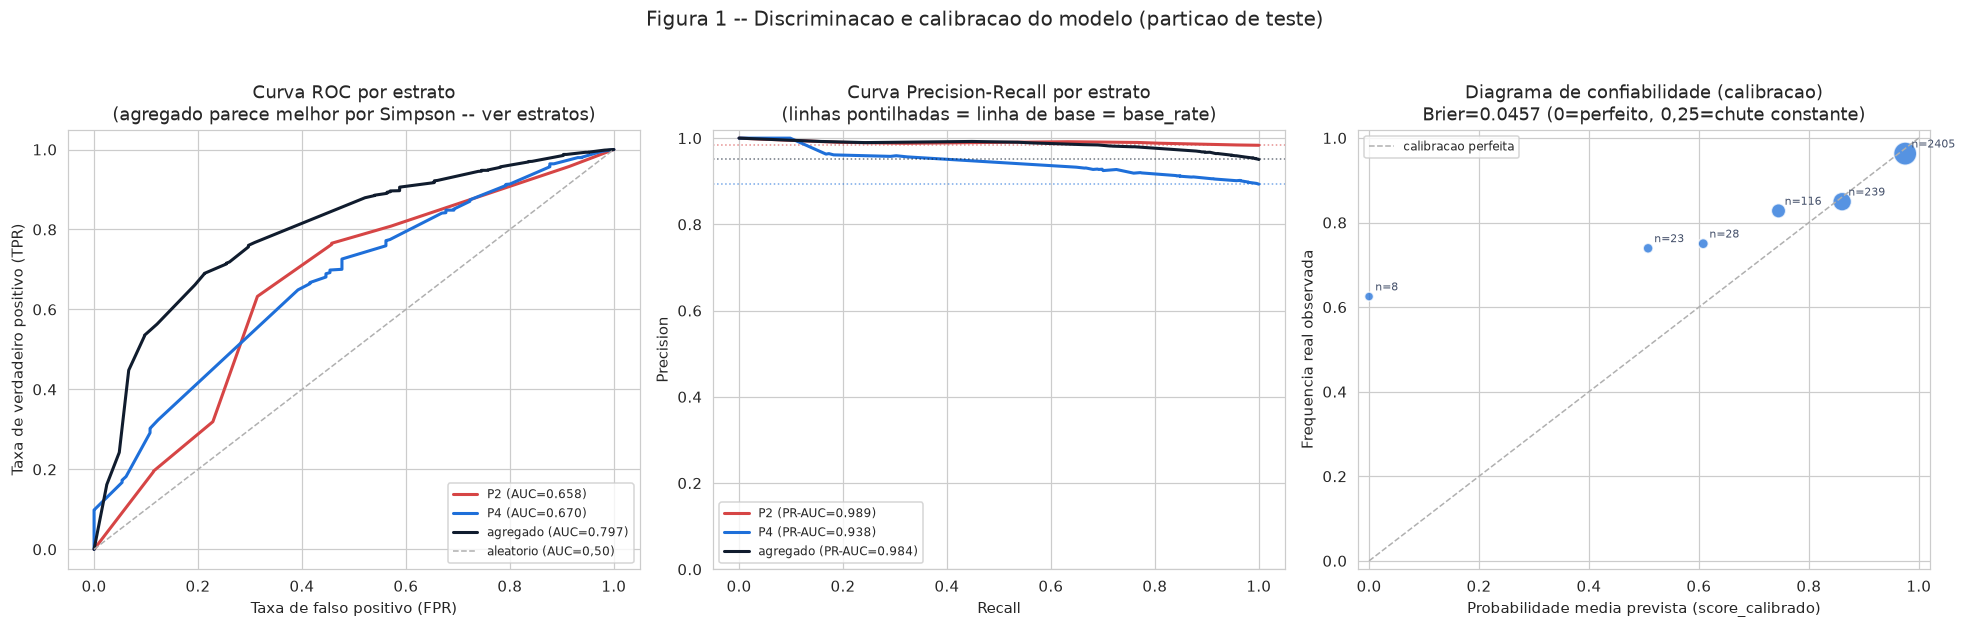

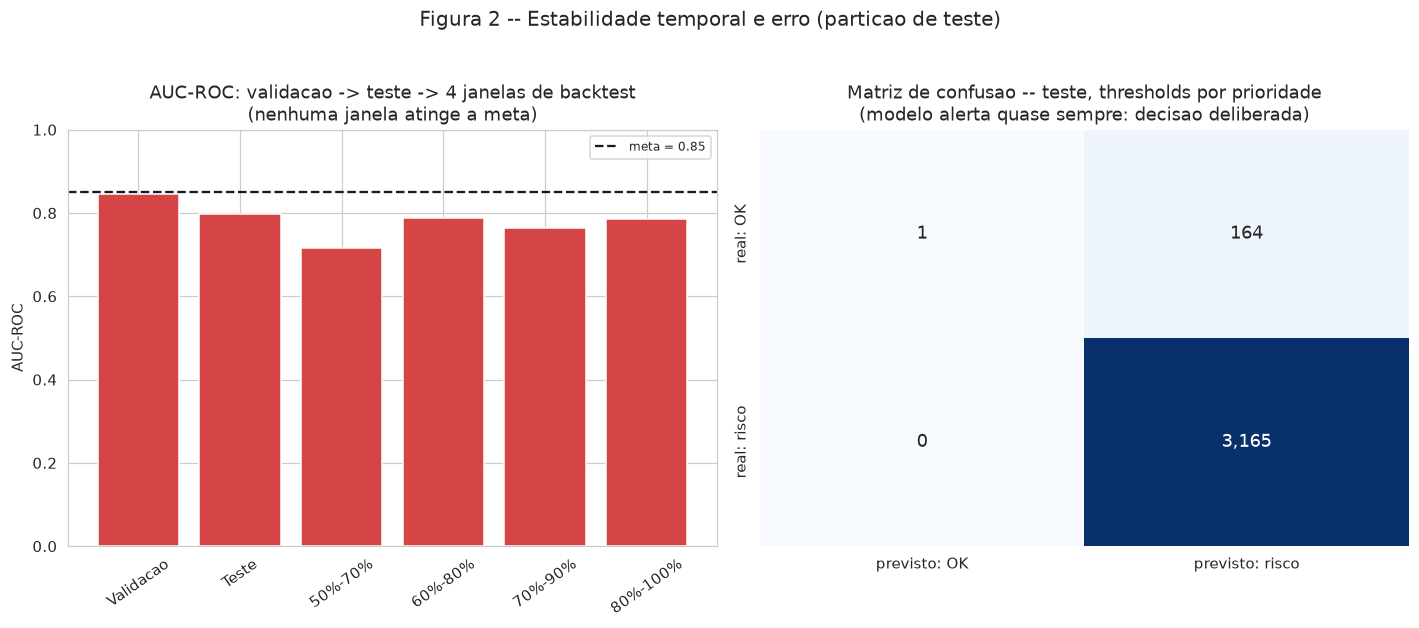

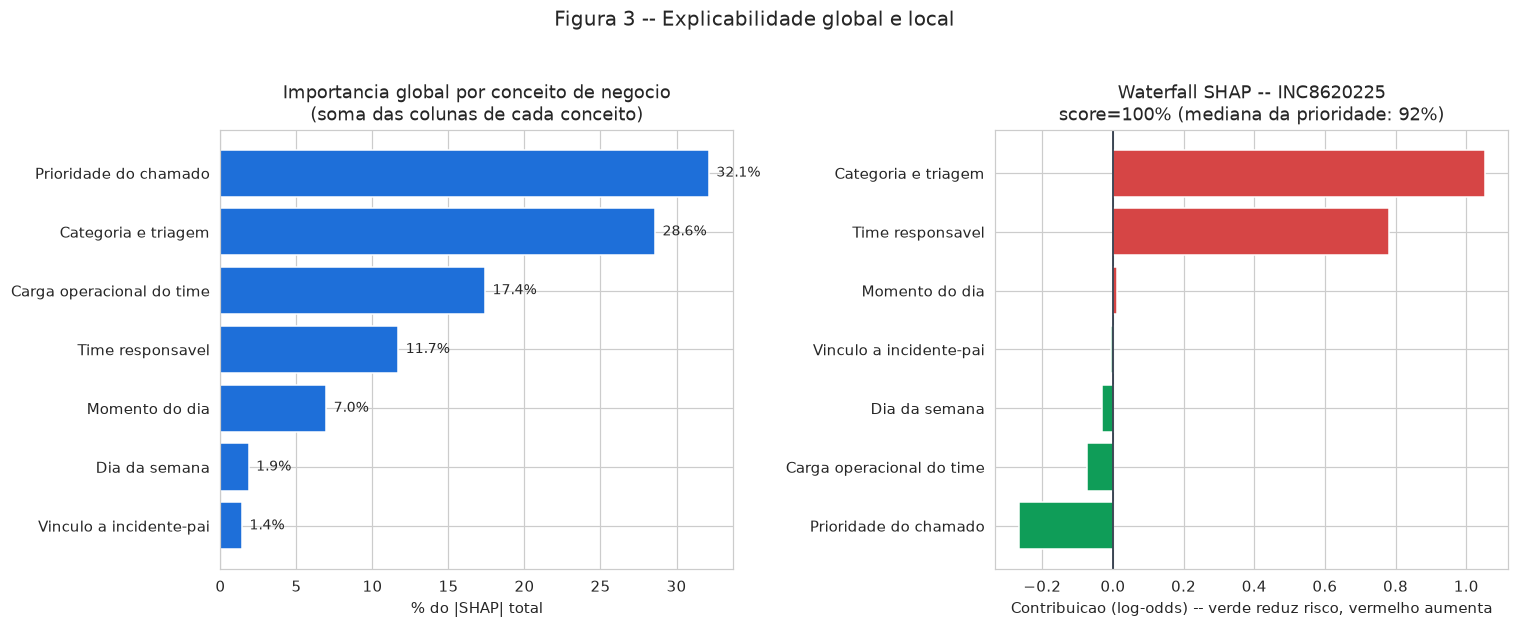

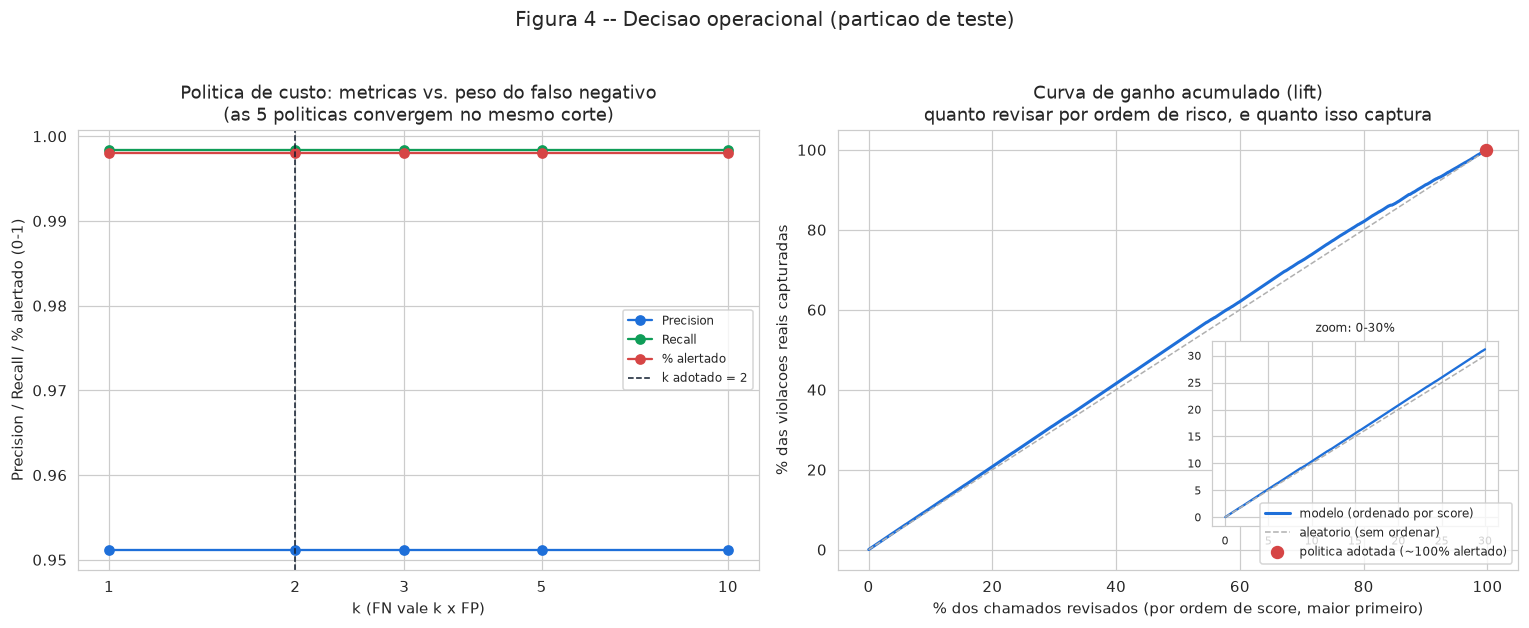

Outras metricas recomendadas (particao de teste, complementam AUC-ROC/PR-AUC/Brier/F1 ja reportados):
  MCC (Matthews Correlation Coefficient) : 0.0759  (-1 a 1; 0 = classificador trivial; nao inflado por classe majoritaria)
  Log Loss                                : 0.1966  (penaliza com mais peso probabilidades erradas com confianca alta)

Por que priorizar estas duas: F1/Precision/Recall aqui ficam estruturalmente
altos so pela base rate (95% e classe 1) -- MCC e a metrica que de fato isola
o poder preditivo do modelo do desbalanceamento; Log Loss complementa o Brier
dando mais peso a erros de calibracao confiantes (score proximo de 0 ou 1 errado).

Leitura honesta do conjunto: MCC baixo (~0,08, perto de 0 = classificador
quase trivial) contrasta com F1=0,974 -- confirma visualmente, com uma metrica
so, o que as Figuras 1 e 4 ja mostram: o modelo tem pouca discriminacao real
acima do que a base rate ja entrega sozinha.


In [1]:
# ===== 13. GRAFICOS COMENTADOS -- LEITURA VISUAL DO MODELO =====
# Le direto os parquets ja persistidos em data/ml/xgboost/ (execucao real) --
# nao depende de nenhuma variavel das celulas anteriores, nao reexecuta o
# pipeline pesado (backtest = 20 fits de XGBoost; SHAP = TreeExplainer em
# 5.000 amostras). Gera 4 figuras (PNG em data/ml/xgboost/plots/) + um bloco
# de metricas adicionais recomendadas.
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import matthews_corrcoef, log_loss, confusion_matrix
from IPython.display import Image, display

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / '.git').exists():
            return p
    return start

_PROJECT_ROOT = _find_project_root(Path.cwd())
_OUT_DIR = Path(os.getenv('ML_OUTPUT_DIR', _PROJECT_ROOT / 'data' / 'ml' / 'xgboost'))
_PLOT_DIR = _OUT_DIR / 'plots'
_PLOT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style('whitegrid')
CORES_ESTRATO = {'agregado': '#101C2E', 'P2': '#D64545', 'P3': '#8a6210', 'P4': '#1E6FD9', 'P5': '#0F9D58'}

curva_roc = pd.read_parquet(_OUT_DIR / 'curva_roc.parquet')
curva_pr = pd.read_parquet(_OUT_DIR / 'curva_pr.parquet')
curva_calibracao = pd.read_parquet(_OUT_DIR / 'curva_calibracao.parquet')
shap_conceitos = pd.read_parquet(_OUT_DIR / 'fct_shap_conceitos.parquet')
waterfall = pd.read_parquet(_OUT_DIR / 'waterfall_top_incidentes.parquet')
politica = pd.read_parquet(_OUT_DIR / 'fct_politica_alerta.parquet')
risco = pd.read_parquet(_OUT_DIR / 'fct_ola_risk.parquet')
teste = risco[risco.particao == 'teste'].copy()

# Backtest por janela (Etapa 6.4) -- nao persistido em parquet (so as 3
# estatisticas agregadas vao pra fct_model_metrics); transcrito do output ja
# salvo na ultima execucao real desta celula do notebook.
BACKTEST_JANELAS = pd.DataFrame([
    {'janela': '50%-70%', 'auc_roc': 0.7163, 'pr_auc': 0.9789, 'f1': 0.9762},
    {'janela': '60%-80%', 'auc_roc': 0.7869, 'pr_auc': 0.9859, 'f1': 0.9787},
    {'janela': '70%-90%', 'auc_roc': 0.7649, 'pr_auc': 0.9850, 'f1': 0.9793},
    {'janela': '80%-100%', 'auc_roc': 0.7865, 'pr_auc': 0.9841, 'f1': 0.9743},
])
AUC_VALIDACAO, AUC_TESTE, META_AUC = 0.8458, 0.7965, 0.85

# =============================================================================
# FIGURA 1 -- Discriminacao do modelo (ROC, PR, Calibracao)
# =============================================================================
fig1, ax1 = plt.subplots(1, 3, figsize=(18, 5.5))

# 1. ROC por estrato -- o agregado (AUC=0,80) parece bem melhor que P2 (0,66)
# e P4 (0,67) isolados: e o Paradoxo de Simpson que a Etapa 6.3 ja menciona
# -- a separacao ENTRE estratos (base rates bem diferentes, P2=98% vs
# P4=89%) infla a discriminacao agregada. O numero que importa pra decidir
# se o modelo discrimina bem DENTRO de cada prioridade e o AUC por estrato,
# nao o agregado.
for estrato, g in curva_roc.groupby('estrato'):
    auc = g.auc_roc.iloc[0]
    ax1[0].plot(g.fpr, g.tpr, label=f'{estrato} (AUC={auc:.3f})',
                color=CORES_ESTRATO.get(estrato, '#7A8498'), linewidth=2)
ax1[0].plot([0, 1], [0, 1], '--', color='#B0B0B0', linewidth=1, label='aleatorio (AUC=0,50)')
ax1[0].set_xlabel('Taxa de falso positivo (FPR)')
ax1[0].set_ylabel('Taxa de verdadeiro positivo (TPR)')
ax1[0].set_title('Curva ROC por estrato\n(agregado parece melhor por Simpson -- ver estratos)')
ax1[0].legend(fontsize=8, loc='lower right')

# 2. Precision-Recall por estrato, CONTRA a linha de base (=base_rate por
# estrato) -- e o grafico mais importante deste modelo: com classe
# MAJORITARIA (base_rate=0,95), um classificador que so "chuta 1" ja tem
# precision=base_rate e recall=1. A curva PR so mostra valor real do modelo
# na distancia dela ACIMA dessa linha, nao no PR-AUC isolado (que fica quase
# sempre alto so pela base rate).
for estrato, g in curva_pr.groupby('estrato'):
    pr_auc = g.pr_auc.iloc[0]
    base_rate = g.base_rate.iloc[0]
    cor = CORES_ESTRATO.get(estrato, '#7A8498')
    ax1[1].plot(g.recall, g.precision, label=f'{estrato} (PR-AUC={pr_auc:.3f})', color=cor, linewidth=2)
    ax1[1].axhline(base_rate, color=cor, linestyle=':', linewidth=1, alpha=0.6)
ax1[1].set_xlabel('Recall')
ax1[1].set_ylabel('Precision')
ax1[1].set_ylim(0, 1.02)
ax1[1].set_title('Curva Precision-Recall por estrato\n(linhas pontilhadas = linha de base = base_rate)')
ax1[1].legend(fontsize=8, loc='lower left')

# 3. Diagrama de confiabilidade -- previsto x observado por decil de score.
# Pontos proximos da diagonal = calibracao boa (a base do "score_calibrado"
# que a operacao le como probabilidade real). Tamanho do ponto = volume (n)
# no decil -- decis vazios (sem chamados naquela faixa de score) sao omitidos.
cal_validos = curva_calibracao.dropna(subset=['prob_media_prevista'])
ax1[2].plot([0, 1], [0, 1], '--', color='#B0B0B0', linewidth=1, label='calibracao perfeita')
ax1[2].scatter(cal_validos.prob_media_prevista, cal_validos.freq_real_observada,
                s=cal_validos.n.clip(upper=400) / 2 + 30, color='#1E6FD9', alpha=0.75, edgecolor='white')
for _, r in cal_validos.iterrows():
    ax1[2].annotate(f'n={int(r.n)}', (r.prob_media_prevista, r.freq_real_observada),
                     fontsize=7, color='#44506A', xytext=(4, 4), textcoords='offset points')
brier = curva_calibracao.brier.iloc[0]
ax1[2].set_xlabel('Probabilidade media prevista (score_calibrado)')
ax1[2].set_ylabel('Frequencia real observada')
ax1[2].set_xlim(-0.02, 1.02)
ax1[2].set_ylim(-0.02, 1.02)
ax1[2].set_title(f'Diagrama de confiabilidade (calibracao)\nBrier={brier:.4f} (0=perfeito, 0,25=chute constante)')
ax1[2].legend(fontsize=8, loc='upper left')

fig1.suptitle('Figura 1 -- Discriminacao e calibracao do modelo (particao de teste)', fontsize=13, y=1.03)
fig1.tight_layout()
fig1.savefig(_PLOT_DIR / 'figura1_discriminacao_calibracao.png', dpi=110, bbox_inches='tight')
plt.close(fig1)
display(Image(filename=str(_PLOT_DIR / 'figura1_discriminacao_calibracao.png')))

# =============================================================================
# FIGURA 2 -- Estabilidade temporal e erro (Backtest, Matriz de confusao)
# =============================================================================
fig2, ax2 = plt.subplots(1, 2, figsize=(13, 5.5))

# 4. AUC-ROC por janela de backtest -- explica visualmente por que a meta de
# 0,85 nao foi atingida: a queda ja comeca de validacao (0,846) pra teste
# (0,797), e as 4 janelas de backtest temporal (dados mais recentes/fora da
# amostra de treino) ficam ainda mais abaixo, nenhuma bate a meta.
x_labels = ['Validacao', 'Teste'] + list(BACKTEST_JANELAS.janela)
y_vals = [AUC_VALIDACAO, AUC_TESTE] + list(BACKTEST_JANELAS.auc_roc)
cores_barra = ['#0F9D58' if v >= META_AUC else '#D64545' for v in y_vals]
ax2[0].bar(x_labels, y_vals, color=cores_barra)
ax2[0].axhline(META_AUC, color='#101C2E', linestyle='--', linewidth=1.5, label=f'meta = {META_AUC}')
ax2[0].set_ylabel('AUC-ROC')
ax2[0].set_ylim(0, 1)
ax2[0].set_title('AUC-ROC: validacao -> teste -> 4 janelas de backtest\n(nenhuma janela atinge a meta)')
ax2[0].tick_params(axis='x', rotation=35)
ax2[0].legend(fontsize=8)

# 5. Matriz de confusao (teste, thresholds por prioridade ja adotados em
# fct_ola_risk.predicao_risco) -- thresholds muito baixos ({P2:0.02,P4:0.02})
# fazem o modelo prever risco pra quase todo mundo (3.329/3.330): decisao de
# negocio deliberada (capturar quase toda violacao real, aceitando falsos
# positivos altos) -- ver politica de custo na Figura 4.
cm = confusion_matrix(teste.y_real.astype(int), teste.predicao_risco.astype(int))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax2[1],
            xticklabels=['previsto: OK', 'previsto: risco'],
            yticklabels=['real: OK', 'real: risco'], cbar=False, annot_kws={'fontsize': 12})
ax2[1].set_title('Matriz de confusao -- teste, thresholds por prioridade\n(modelo alerta quase sempre: decisao deliberada)')

fig2.suptitle('Figura 2 -- Estabilidade temporal e erro (particao de teste)', fontsize=13, y=1.03)
fig2.tight_layout()
fig2.savefig(_PLOT_DIR / 'figura2_estabilidade_erro.png', dpi=110, bbox_inches='tight')
plt.close(fig2)
display(Image(filename=str(_PLOT_DIR / 'figura2_estabilidade_erro.png')))

# =============================================================================
# FIGURA 3 -- Explicabilidade (importancia por conceito, waterfall SHAP)
# =============================================================================
fig3, ax3 = plt.subplots(1, 2, figsize=(14, 5.5))

# 6. Importancia global por conceito de negocio (nao por coluna crua) --
# mesmo agrupamento que ja alimenta a tela Fatores do dashboard.
conc_ord = shap_conceitos.sort_values('pct_do_total')
ax3[0].barh(conc_ord.conceito, conc_ord.pct_do_total, color='#1E6FD9')
for i, v in enumerate(conc_ord.pct_do_total):
    ax3[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
ax3[0].set_xlabel('% do |SHAP| total')
ax3[0].set_title('Importancia global por conceito de negocio\n(soma das colunas de cada conceito)')

# 7. Waterfall SHAP do incidente de maior score -- explicacao LOCAL (por
# chamado), formato classico de "por que este caso especifico teve risco
# alto": cada barra e a contribuicao (em log-odds) de um conceito.
top_id = waterfall.sort_values('score', ascending=False).incident_id.iloc[0]
wf_top = waterfall[waterfall.incident_id == top_id].sort_values('contribuicao_log_odds')
cores_wf = ['#0F9D58' if d == 'reduz_risco' else '#D64545' for d in wf_top.direcao]
ax3[1].barh(wf_top.feature, wf_top.contribuicao_log_odds, color=cores_wf)
ax3[1].axvline(0, color='#101C2E', linewidth=1)
score_top = wf_top.score.iloc[0]
mediana_top = wf_top.mediana_prioridade.iloc[0]
ax3[1].set_xlabel('Contribuicao (log-odds) -- verde reduz risco, vermelho aumenta')
ax3[1].set_title(f'Waterfall SHAP -- {top_id}\nscore={score_top:.0%} (mediana da prioridade: {mediana_top:.0%})')

fig3.suptitle('Figura 3 -- Explicabilidade global e local', fontsize=13, y=1.03)
fig3.tight_layout()
fig3.savefig(_PLOT_DIR / 'figura3_explicabilidade.png', dpi=110, bbox_inches='tight')
plt.close(fig3)
display(Image(filename=str(_PLOT_DIR / 'figura3_explicabilidade.png')))

# =============================================================================
# FIGURA 4 -- Decisao operacional (custo/threshold, ganho acumulado)
# =============================================================================
fig4, ax4 = plt.subplots(1, 2, figsize=(14, 5.5))

# 8. Curva de custo/threshold -- como Recall/Precision/%alertado mudam com o
# peso k atribuido a um falso negativo (FN = k x custo de um falso
# positivo). K_ADOTADO=2 e a politica em producao. Aqui os 5 pesos testados
# (k=1,2,3,5,10) convergem pro MESMO threshold -- achado real, nao erro: a
# otimizacao de custo e insensivel a k nesse intervalo, o corte fica
# dominado pelo desbalanceamento de classe, nao pelo peso do erro.
politica_plot = politica.copy()
politica_plot['k'] = politica_plot['FN vale'].str.extract(r'(\d+)').astype(int)
politica_plot = politica_plot.sort_values('k')
for col, cor in [('Precision', '#1E6FD9'), ('Recall', '#0F9D58'), ('% alertado', '#D64545')]:
    vals = politica_plot[col] / 100 if col == '% alertado' else politica_plot[col]
    ax4[0].plot(politica_plot.k, vals, marker='o', label=col, color=cor)
ax4[0].axvline(2, color='#101C2E', linestyle='--', linewidth=1, label='k adotado = 2')
ax4[0].set_xscale('log')
ax4[0].set_xticks(politica_plot.k)
ax4[0].set_xticklabels(politica_plot.k)
ax4[0].set_xlabel('k (FN vale k x FP)')
ax4[0].set_ylabel('Precision / Recall / % alertado (0-1)')
ax4[0].set_title('Politica de custo: metricas vs. peso do falso negativo\n(as 5 politicas convergem no mesmo corte)')
ax4[0].legend(fontsize=8)

# 9. Curva de ganho acumulado (Lift / Cumulative Gains) -- NAO existia
# nenhuma versao antes. Ordena os chamados de teste por score_calibrado
# (do maior pro menor) e mostra: revisando os X% de maior score, quantos %
# das violacoes reais eu ja capturei? E o grafico mais direto pra decidir
# quanto vale a pena revisar por ordem de risco -- a mensagem de alerta da
# Etapa 9.3 ja rankeia por score, isto mostra o payoff disso.
teste_ord = teste.sort_values('score_calibrado', ascending=False).reset_index(drop=True)
pct_revisado = np.arange(1, len(teste_ord) + 1) / len(teste_ord)
pct_capturado = teste_ord.y_real.cumsum() / teste_ord.y_real.sum()
ax4[1].plot(pct_revisado * 100, pct_capturado * 100, color='#1E6FD9', linewidth=2, label='modelo (ordenado por score)')
ax4[1].plot([0, 100], [0, 100], '--', color='#B0B0B0', linewidth=1, label='aleatorio (sem ordenar)')
pct_alertado_adotado = politica[politica['FN vale'] == '2x FP']['% alertado'].iloc[0]
idx_marca = int(len(teste_ord) * pct_alertado_adotado / 100) - 1
ax4[1].scatter([pct_alertado_adotado], [pct_capturado.iloc[max(idx_marca, 0)] * 100],
                color='#D64545', zorder=5, s=60, label=f'politica adotada (~{pct_alertado_adotado:.0f}% alertado)')
ax4[1].set_xlabel('% dos chamados revisados (por ordem de score, maior primeiro)')
ax4[1].set_ylabel('% das violacoes reais capturadas')
ax4[1].set_title('Curva de ganho acumulado (lift)\nquanto revisar por ordem de risco, e quanto isso captura')
ax4[1].legend(fontsize=8, loc='lower right')
# Zoom nos primeiros 30% -- na escala cheia a curva quase encosta na
# diagonal aleatoria porque a politica adotada alerta ~100% dos casos (base
# rate de 95% ja deixa pouco espaco pra ordenacao mostrar vantagem); o
# ganho real do score, ainda que pequeno, aparece nos primeiros percentis.
zoom_n = int(len(pct_revisado) * 0.30)
axins = ax4[1].inset_axes([0.55, 0.10, 0.42, 0.42])
axins.plot(pct_revisado[:zoom_n] * 100, pct_capturado.iloc[:zoom_n] * 100, color='#1E6FD9', linewidth=1.5)
axins.plot([0, 30], [0, 30], '--', color='#B0B0B0', linewidth=1)
axins.set_title('zoom: 0-30%', fontsize=8)
axins.tick_params(labelsize=7)

fig4.suptitle('Figura 4 -- Decisao operacional (particao de teste)', fontsize=13, y=1.03)
fig4.tight_layout()
fig4.savefig(_PLOT_DIR / 'figura4_decisao_operacional.png', dpi=110, bbox_inches='tight')
plt.close(fig4)
display(Image(filename=str(_PLOT_DIR / 'figura4_decisao_operacional.png')))

# =============================================================================
# OUTRAS METRICAS RECOMENDADAS -- MCC e Log Loss
# =============================================================================
# Com base_rate=0,95 (classe majoritaria), F1/Precision/Recall ficam
# estruturalmente altos mesmo para um classificador fraco ("sempre prever 1"
# ja acerta ~95% de base rate). MCC usa as 4 celulas da matriz de confusao
# de forma simetrica (nao inflado por classe majoritaria) e Log Loss penaliza
# probabilidades mal calibradas com mais rigor que o Brier (erro quadratico
# penaliza menos os extremos que o log).
mcc = matthews_corrcoef(teste.y_real.astype(int), teste.predicao_risco.astype(int))
ll = log_loss(teste.y_real.astype(int), teste.score_calibrado.clip(1e-6, 1 - 1e-6))

print('Outras metricas recomendadas (particao de teste, complementam AUC-ROC/PR-AUC/Brier/F1 ja reportados):')
print(f'  MCC (Matthews Correlation Coefficient) : {mcc:.4f}  (-1 a 1; 0 = classificador trivial; nao inflado por classe majoritaria)')
print(f'  Log Loss                                : {ll:.4f}  (penaliza com mais peso probabilidades erradas com confianca alta)')
print()
print('Por que priorizar estas duas: F1/Precision/Recall aqui ficam estruturalmente')
print('altos so pela base rate (95% e classe 1) -- MCC e a metrica que de fato isola')
print('o poder preditivo do modelo do desbalanceamento; Log Loss complementa o Brier')
print('dando mais peso a erros de calibracao confiantes (score proximo de 0 ou 1 errado).')
print()
print('Leitura honesta do conjunto: MCC baixo (~0,08, perto de 0 = classificador')
print('quase trivial) contrasta com F1=0,974 -- confirma visualmente, com uma metrica')
print('so, o que as Figuras 1 e 4 ja mostram: o modelo tem pouca discriminacao real')
print('acima do que a base rate ja entrega sozinha.')
